In [ ]:
# load librairies
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt
import os
from os.path import join
import seaborn as sns
import statsmodels.api as sm
import scipy
import json
import statsmodels.formula.api as smf
from collections import defaultdict
from scipy.stats import wilcoxon, ttest_rel

from functions import utils, plotting, io, behav_analysis, stats_tests

In [2]:
# pick format to save figures : png for quick visualization, pdf for illustrator
save_as = 'png'
color_dict = {
    'DBS ON': '#20a39e', 
    'DBS OFF': '#ef5b5b', 
    'control': '#ffba49', 
    'preop': '#8E7DBE',
    'Session 1': "#206ea1", 
    'Session 2': "#5FA363", 
    }
visualize_by = 'subject' # pick whether to visualize by condition (DBS ON, DBS OFF, control) or by subject id


# 1. Select subjects, create color palette and load data #

In [3]:
# Use the Included or excluded.xlsx document:
onedrive_path = utils._get_onedrive_path()

working_path = os.path.dirname(os.getcwd())
results_path = join(working_path, "results")
behav_results_saving_path = join(results_path, "behav_results")
if not os.path.isdir(behav_results_saving_path):
    os.makedirs(behav_results_saving_path)

# read the json file containing the included and excluded subjects
# Open and read the JSON file
included_excluded_file = join(results_path, 'final_included_subjects.json')
with open(included_excluded_file, 'r') as file:
    included_subjects = json.load(file)   

In [4]:
included_subjects

['C003 mSST',
 'C004 mSST',
 'C006 mSST',
 'C007 mSST',
 'C008 mSST',
 'C009 mSST',
 'C010 mSST',
 'C011 mSST',
 'C012 mSST',
 'C013 mSST',
 'C014 mSST',
 'C015 mSST',
 'sub006 DBS ON mSST',
 'sub006 DBS OFF mSST',
 'sub011 DBS OFF mSST',
 'sub011 DBS ON mSST',
 'sub012 DBS ON mSST',
 'sub012 DBS OFF mSST',
 'sub015 DBS OFF mSST',
 'sub015 DBS ON mSST',
 'sub019 DBS ON mSST',
 'sub019 DBS OFF mSST',
 'sub023 DBS OFF mSST',
 'sub023 DBS ON mSST',
 'sub025 DBS ON mSST',
 'sub025 DBS OFF mSST',
 'sub027 DBS ON mSST',
 'sub027 DBS OFF mSST',
 'sub028 DBS OFF mSST',
 'sub028 DBS ON mSST',
 'sub029 DBS ON mSST',
 'sub029 DBS OFF mSST',
 'sub032 DBS ON mSST',
 'sub032 DBS OFF mSST',
 'sub033 DBS ON mSST',
 'sub033 DBS OFF mSST']

In [4]:
subject_colors = utils.create_color_palette(included_subjects)
utils.plot_color_palette(
    subject_colors = subject_colors,
    save_as='png', 
    saving_path=behav_results_saving_path
    )

['C003', 'C004', 'C006', 'C007', 'C008', 'C009', 'C010', 'C011', 'C012', 'C013', 'C014', 'C015', 'sub006', 'sub011', 'sub012', 'sub015', 'sub019', 'sub023', 'sub025', 'sub027', 'sub028', 'sub029', 'sub032', 'sub033']


In [5]:
# load excel files for all included subjects and extract stats
data = io.load_behav_data(included_subjects, onedrive_path)
stats = utils.extract_stats(data)

C003 mSST
C004 mSST
C006 mSST
C007 mSST
C008 mSST
C009 mSST
C010 mSST
C011 mSST
C012 mSST
C013 mSST
C014 mSST
C015 mSST
sub006 DBS ON mSST
sub006 DBS OFF mSST
sub011 DBS OFF mSST
sub011 DBS ON mSST
sub012 DBS ON mSST
sub012 DBS OFF mSST
sub015 DBS OFF mSST
sub015 DBS ON mSST
sub019 DBS ON mSST
sub019 DBS OFF mSST
sub023 DBS OFF mSST
sub023 DBS ON mSST
sub025 DBS ON mSST
sub025 DBS OFF mSST
sub027 DBS ON mSST
sub027 DBS OFF mSST
sub028 DBS OFF mSST
sub028 DBS ON mSST
sub029 DBS ON mSST
sub029 DBS OFF mSST
sub032 DBS ON mSST
sub032 DBS OFF mSST
sub033 DBS ON mSST
sub033 DBS OFF mSST


In [6]:
# fetch excel file containing recording and subject information
excel_file = join(onedrive_path, 'WP3_rec_info.xlsx')
# select the relevant sheet called 'Subjects List'
subject_info_df = pd.read_excel(excel_file, sheet_name='Subjects List')
control_info_df = pd.read_excel(excel_file, sheet_name='Controls List')

# get session order and save it to 'session_info.txt'
behav_analysis.get_session_order(
    included_subjects = included_subjects,
    subject_info_df = subject_info_df,
    behav_results_saving_path = behav_results_saving_path
)


6 subjects started with first session in OFF condition
6 subjects started with first session in ON condition


# 2. RT per trial type and condition/subject #

## 2.1. Visualization ##

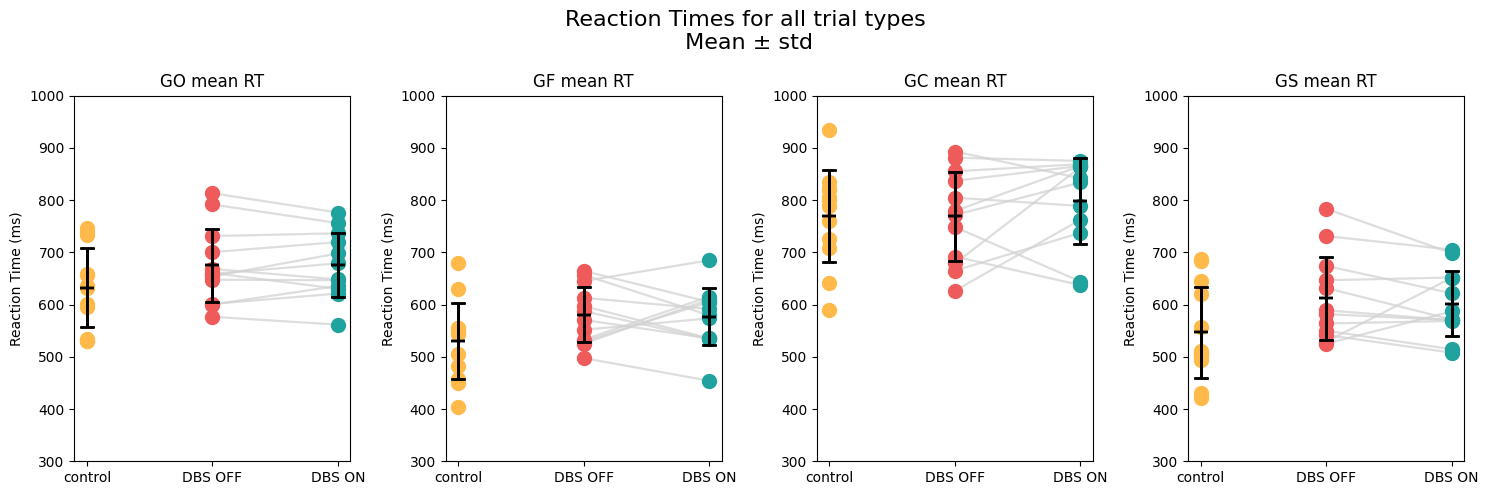

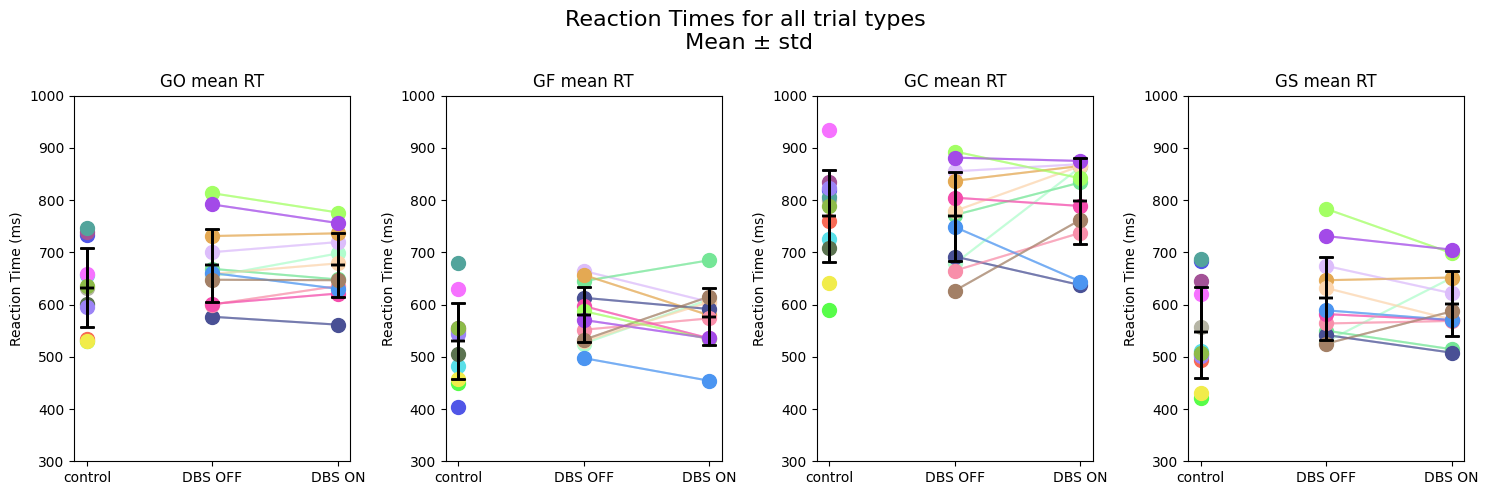

In [7]:
temp_save = join(behav_results_saving_path, "Reaction times")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)    
for color in ['condition', 'subject']:    
    behav_analysis.plot_rt_all(
        stats = stats,
        color_dict = color_dict,
        subject_colors = subject_colors,
        colored_by = color,
        saving_path = temp_save,
        save_as = save_as,
        show_plot = True
    )   

## 2.2. Analysis using a linear mixed-effect model ##

RT ~ DBS_condition × Trial_type + (1 + DBS_condition | Subject) --> Tests whether RT depends on trial type and whether DBS changes RT differently across trial types, with GO under DBS OFF as the reference. 

In [ ]:
""" 
First model with just a random intercept per subject, no random slopes.
Log-likelihood is infinite.
"""

# # Initialize empty dictionaries
# stats_OFF = {}
# stats_ON = {}
# stats_CONTROL = {}
# stats_PREOP = {}

# # Loop through the original dictionary and filter into sub-dictionaries
# for key, value in stats.items():
#     if "OFF" in key:
#         stats_OFF[key] = value
#     elif "ON" in key:
#         stats_ON[key] = value
#     elif "C" in key:
#         stats_CONTROL[key] = value
#     elif "preop" in key:
#         stats_PREOP[key] = value

# # Define conditions and corresponding dictionaries
# conditions = {
#     'control': stats_CONTROL,
#     'DBS OFF': stats_OFF,
#     'DBS ON': stats_ON,
# }

# # Initialize dictionaries to hold results for each condition
# results = {condition: {} for condition in conditions.keys()}
# # Loop through each condition and subject
# for condition, data_dict in conditions.items():
#     for subject_id, metrics in data_dict.items():
#         # Extract the subject ID (first part of subject_id before the first space)
#         sub_id = subject_id.split()[0]
#         # Retrieve the required metrics and store them in the result dictionary
#         go_rt = metrics['go_trial RTs (ms)']
#         gc_rt = metrics['go_continue_trial RTs (ms)']
#         gs_rt = metrics['stop_trial RTs (ms)']
#         gf_rt = metrics['go_fast_trial RTs (ms)']
#         results[condition][sub_id] = {
#             'go_rt': go_rt,
#             'gc_rt': gc_rt,
#             'gs_rt': gs_rt,
#             'gf_rt': gf_rt
#         }



# rows = []

# for condition in ['DBS OFF', 'DBS ON']:

#     for subject_id, metrics in results[condition].items():

#         trial_data = {
#             'GO': metrics['go_rt'],
#             'GC': metrics['gc_rt'],
#             'GS': metrics['gs_rt'],
#             'GF': metrics['gf_rt']
#         }

#         for trial_type, rt_values in trial_data.items():

#             # Convert to numpy array
#             rt_values = np.asarray(rt_values, dtype=float)

#             # Keep EVERY individual RT
#             for rt in rt_values:

#                 # Skip missing values
#                 if np.isfinite(rt):

#                     rows.append({
#                         'Subject': subject_id,
#                         'Condition': condition,
#                         'Trial_type': trial_type,
#                         'RT': rt
#                     })


# # Create dataframe
# df = pd.DataFrame(rows)


# # ============================================================
# # CATEGORICAL VARIABLES
# # ============================================================

# # DBS OFF = reference condition
# df["Condition"] = pd.Categorical(
#     df["Condition"],
#     categories=["DBS OFF", "DBS ON"]
# )

# # GO = reference trial type
# df["Trial_type"] = pd.Categorical(
#     df["Trial_type"],
#     categories=["GO", "GC", "GS", "GF"]
# )


# # ============================================================
# # CHECK DATA
# # ============================================================

# # print(df.head())

# # print("\nNumber of trials:")
# # print(len(df))

# # print("\nTrials per subject:")
# # print(df.groupby("Subject").size())

# # print("\nTrials per condition:")
# # print(df.groupby("Condition").size())

# # print("\nTrials per trial type:")
# # print(df.groupby("Trial_type").size())

# # ============================================================
# # 5. SIMPLE TRIAL-LEVEL LMM
# # ============================================================

# model = smf.mixedlm(
#     "RT ~ Condition * Trial_type",
#     data=df,
#     groups=df["Subject"]
# )

# result = model.fit(
#     reml=True,
#     method="lbfgs"
# )

# print("\n")
# print(result.summary())



                       Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          RT        
No. Observations:           7561             Method:                      REML      
No. Groups:                 12               Scale:                       25523.5829
Min. group size:            554              Log-Likelihood:              inf       
Max. group size:            742              Converged:                   Yes       
Mean group size:            630.1                                                   
------------------------------------------------------------------------------------
                                      Coef.  Std.Err.    z    P>|z|  [0.025   0.975]
------------------------------------------------------------------------------------
Intercept                            -11.841                                        
Condition[T.DBS ON]                    2.868    5.057   0.567 0.571   -7.044  12.780
Tr

c:\Users\Juliette\anaconda3\envs\ephy\lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\Juliette\anaconda3\envs\ephy\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
c:\Users\Juliette\anaconda3\envs\ephy\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\Juliette\anaconda3\envs\ephy\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
c:\Users\Juliette\anaconda3\envs\ephy\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positiv

In [67]:
""" 
Second model with a random intercept per subject AND random slopes to account 
for individual differences in the effect of conditions and trial types.
"""

# Initialize empty dictionaries
stats_OFF = {}
stats_ON = {}
stats_CONTROL = {}
stats_PREOP = {}

# Loop through the original dictionary and filter into sub-dictionaries
for key, value in stats.items():
    if "OFF" in key:
        stats_OFF[key] = value
    elif "ON" in key:
        stats_ON[key] = value
    elif "C" in key:
        stats_CONTROL[key] = value
    elif "preop" in key:
        stats_PREOP[key] = value

# Define conditions and corresponding dictionaries
conditions = {
    'control': stats_CONTROL,
    'DBS OFF': stats_OFF,
    'DBS ON': stats_ON,
}

# Initialize dictionaries to hold results for each condition
results = {condition: {} for condition in conditions.keys()}
# Loop through each condition and subject
for condition, data_dict in conditions.items():
    for subject_id, metrics in data_dict.items():
        # Extract the subject ID (first part of subject_id before the first space)
        sub_id = subject_id.split()[0]
        # Retrieve the required metrics and store them in the result dictionary
        go_rt = metrics['go_trial RTs (ms)']
        gc_rt = metrics['go_continue_trial RTs (ms)']
        gs_rt = metrics['stop_trial RTs (ms)']
        gf_rt = metrics['go_fast_trial RTs (ms)']
        results[condition][sub_id] = {
            'go_rt': go_rt,
            'gc_rt': gc_rt,
            'gs_rt': gs_rt,
            'gf_rt': gf_rt
        }



rows = []

for condition in ['DBS OFF', 'DBS ON']:

    for subject_id, metrics in results[condition].items():

        trial_data = {
            'GO': metrics['go_rt'],
            'GC': metrics['gc_rt'],
            'GS': metrics['gs_rt'],
            'GF': metrics['gf_rt']
        }

        for trial_type, rt_values in trial_data.items():

            # Convert to numpy array
            rt_values = np.asarray(rt_values, dtype=float)

            # Keep EVERY individual RT
            for rt in rt_values:

                # Skip missing values
                if np.isfinite(rt):

                    rows.append({
                        'Subject': subject_id,
                        'Condition': condition,
                        'Trial_type': trial_type,
                        'RT': rt
                    })


# Create dataframe
df = pd.DataFrame(rows)


# ============================================================
# CATEGORICAL VARIABLES
# ============================================================

# DBS OFF = reference condition
df["Condition"] = pd.Categorical(
    df["Condition"],
    categories=["DBS OFF", "DBS ON"]
)

# GO = reference trial type
df["Trial_type"] = pd.Categorical(
    df["Trial_type"],
    categories=["GO", "GC", "GS", "GF"]
)


# ============================================================
# CHECK DATA
# ============================================================

# print(df.head())

# print("\nNumber of trials:")
# print(len(df))

# print("\nTrials per subject:")
# print(df.groupby("Subject").size())

# print("\nTrials per condition:")
# print(df.groupby("Condition").size())

# print("\nTrials per trial type:")
# print(df.groupby("Trial_type").size())

# # ============================================================
# # 5. SIMPLE TRIAL-LEVEL LMM
# # ============================================================


model = smf.mixedlm(
    "RT ~ Condition * Trial_type",
    data=df,
    groups=df["Subject"],
    re_formula="1 + Condition"
)

fit_result = model.fit(
    reml=True,
    method="lbfgs"
)

print(fit_result.summary())

                        Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          RT         
No. Observations:            7561             Method:                      REML       
No. Groups:                  12               Scale:                       25225.4714 
Min. group size:             554              Log-Likelihood:              -49056.9564
Max. group size:             742              Converged:                   Yes        
Mean group size:             630.1                                                    
--------------------------------------------------------------------------------------
                                       Coef.   Std.Err.    z    P>|z|  [0.025   0.975]
--------------------------------------------------------------------------------------
Intercept                              673.906   18.271  36.884 0.000  638.095 709.716
Condition[T.DBS ON]                      1.248   12.033   0.104 0.91

A linear mixed-effects model was fitted to RTs, with Condition (DBS OFF/ON), Trial type, and their interaction as fixed effects, and subject-specific random intercepts and Condition slopes. RT differed significantly across trial types. Relative to the reference trial type, GC trials were slower (β = 96.08 ms, SE = 6.90, z = 13.93, p < .001), whereas GS (β = −63.27 ms, SE = 9.35, z = −6.77, p < .001) and GF trials (β = −94.11 ms, SE = 6.93, z = −13.59, p < .001) were faster. There was no evidence for a DBS effect in the reference trial type (β = 1.25 ms, SE = 12.03, z = 0.10, p = .917). However, the DBS × trial-type interaction was significant for GC (β = 29.12 ms, SE = 9.75, z = 2.99, p = .003), indicating that the effect of DBS on RT was approximately 29 ms larger for GC than for the reference trial type. The DBS × trial-type interactions for GS (p = .465) and GF (p = .553) were not significant.

In [68]:
# ---------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------

import re


def plot_lmm_interaction_forest(fit, save_path=None, save_as='png',
                                 title=None, show_plot=True):
    """
    Forest plot of the Condition x Trial_type interaction coefficients from
    your top-down LMM (RT ~ Condition * Trial_type). One glance shows which
    trial types have a DBS-related RT change (CI excludes zero, shown in
    red) vs not (grey). Works directly on the statsmodels fit result --
    auto-detects interaction terms and pulls a short trial-type label out
    of the term name, so it doesn't matter whether your formula was
    'Condition * Trial_type' or 'Trial_type * Condition'.
    """
    params, conf, pvals = fit.params, fit.conf_int(), fit.pvalues
    inter_idx = [i for i in params.index if ':' in i]

    labels, coefs, los, his, ps = [], [], [], [], []
    for idx in inter_idx:
        m = re.search(r'\[T\.([A-Za-z0-9_]+)\]', idx.split(':')[-1])
        labels.append(m.group(1) if m else idx)
        coefs.append(params[idx])
        los.append(conf.loc[idx, 0])
        his.append(conf.loc[idx, 1])
        ps.append(pvals[idx])

    fig, ax = plt.subplots(figsize=(5, 0.7 * len(labels) + 1.5))
    y = np.arange(len(labels))
    coefs, los, his = np.array(coefs), np.array(los), np.array(his)

    ax.errorbar(coefs, y, xerr=[coefs - los, his - coefs],
                fmt='none', ecolor='grey', capsize=3, zorder=1)
    ax.scatter(coefs, y,
               color=['crimson' if p < 0.05 else 'grey' for p in ps],
               s=60, zorder=2)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel('DBS effect on RT relative to reference trial type (ms)')
    ax.set_title(title or 'Condition x Trial-type interaction')
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(join(save_path, f'lmm_interaction_forest.{save_as}'),
                     dpi=300, bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close()

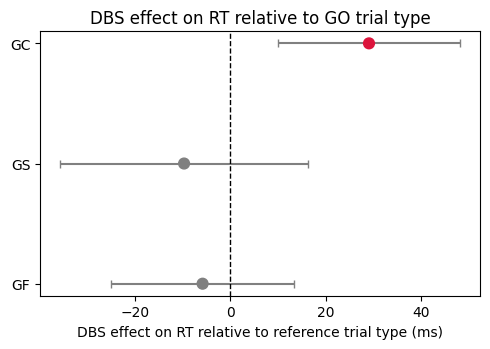

In [69]:
temp_save = join(behav_results_saving_path, "Reaction times")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)

# Figure 1a
plot_lmm_interaction_forest(
    fit = fit_result,
    save_path = temp_save,
    save_as = save_as,
    title = 'DBS effect on RT relative to GO trial type',
    show_plot = True)

# 3. KDE curves #

## 3.1. Grouped ##

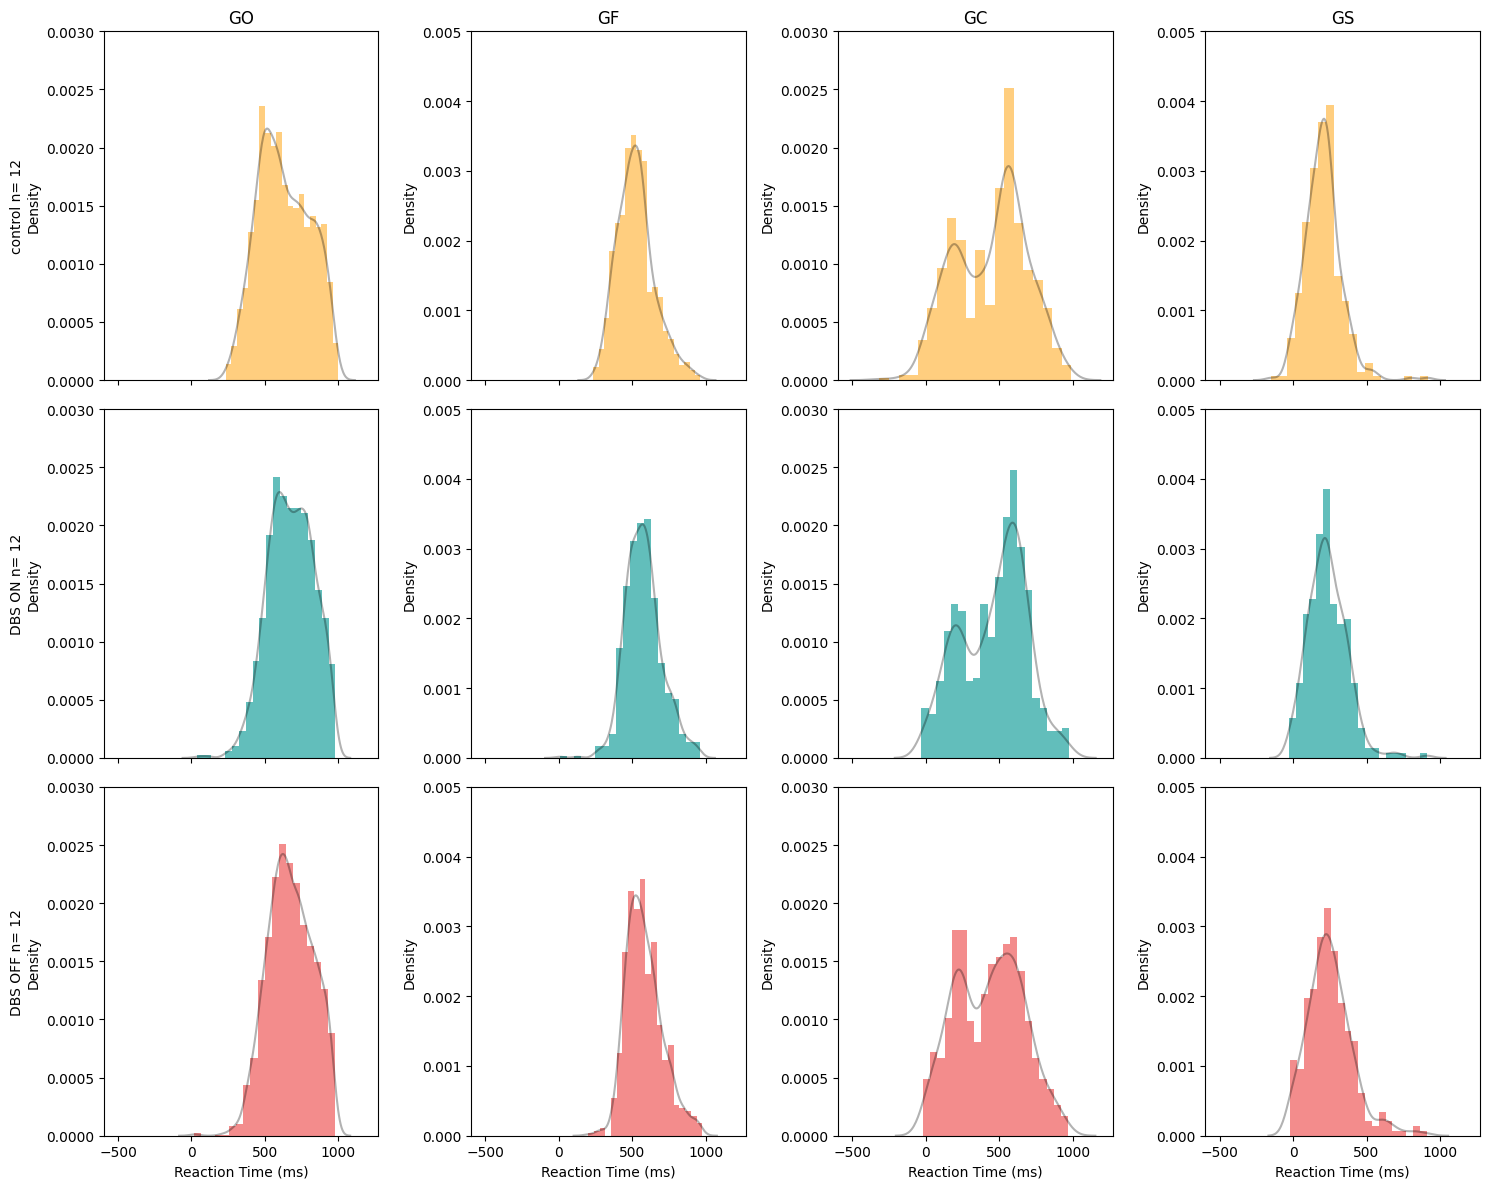

In [16]:
temp_save = join(behav_results_saving_path, "RT distribution")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)    
behav_analysis.visualize_rt_distribution(
    stats = stats,
    color_dict = color_dict,
    saving_path = temp_save,
    save_as = save_as,
    show_plot = True
)

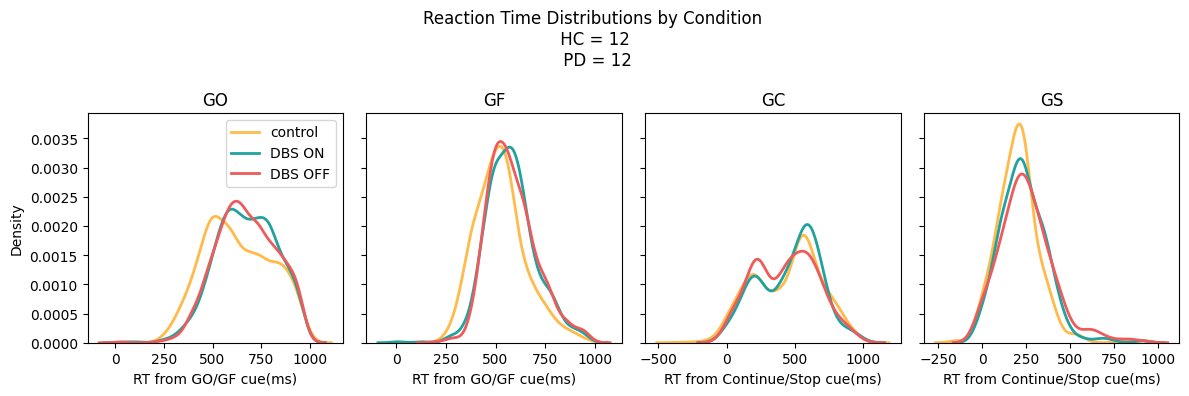

In [10]:
temp_save = join(behav_results_saving_path, "RT distribution")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)    
behav_analysis.visualize_rt_distribution_overlapped(
    stats = stats,
    color_dict = color_dict,
    saving_path = temp_save,
    save_as = save_as,
    show_plot = True
)

GC DBS ON versus DBS OFF

In [70]:
def plot_grand_average_kde(stats, trial_type='GC', color_dict=None,
                            x_range=(0, 1), n_points=1000,
                            rt_key_map=None, save_path=None, save_as='png',
                            title=None, show_plot=True):
    """
    Group-level RT density for one trial type: average the per-subject KDE
    curves across subjects (same per-subject KDE approach as your original
    plot_kde_on_off_per_trial_type), with a shaded +/- SEM band, DBS OFF
    vs ON overlaid on one axis. This is the main qualitative figure -- it
    shows the bimodal shape and the visible weight shift in one glance.
    """
    if color_dict is None:
        color_dict = {'DBS OFF': 'tab:blue', 'DBS ON': 'tab:orange'}
    if rt_key_map is None:
        rt_key_map = {
            'GC': 'GC RTs from continue cue (ms)',
            'GS': 'GS RTs from stop cue (ms)',
            'GO': 'go_trial RTs (ms)',
            'GF': 'go_fast_trial RTs (ms)',
        }
    rt_key = rt_key_map[trial_type]
    x_kde = np.linspace(*x_range, n_points)
    off_subjects = {k: v for k, v in stats.items() if 'OFF' in k}

    fig, ax = plt.subplots(figsize=(6, 4))

    for cond_label in ['DBS OFF', 'DBS ON']:
        curves = []
        for off_key, off_data in off_subjects.items():
            on_key = off_key.replace('OFF', 'ON')
            if on_key not in stats:
                continue
            data = off_data if cond_label == 'DBS OFF' else stats[on_key]
            rts = np.asarray(data.get(rt_key, []), dtype=float)
            rts = rts[np.isfinite(rts)] / 1000.0
            if len(rts) > 1 and len(np.unique(rts)) > 1:
                curves.append(scipy.stats.gaussian_kde(rts)(x_kde))

        curves = np.array(curves)
        mean_curve = curves.mean(axis=0)
        sem_curve = curves.std(axis=0, ddof=1) / np.sqrt(len(curves))
        ax.plot(x_kde, mean_curve, color=color_dict[cond_label],
                label=f'{cond_label} (n={len(curves)})', linewidth=2)
        ax.fill_between(x_kde, mean_curve - sem_curve, mean_curve + sem_curve,
                        color=color_dict[cond_label], alpha=0.2)

    ax.set_xlabel('Reaction time (s)')
    ax.set_ylabel('Density (group mean +/- SEM)')
    ax.set_title(title or f'{trial_type} RT distribution')
    ax.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(join(save_path, f'{trial_type}_grand_average_kde.{save_as}'),
                     dpi=300, bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close()

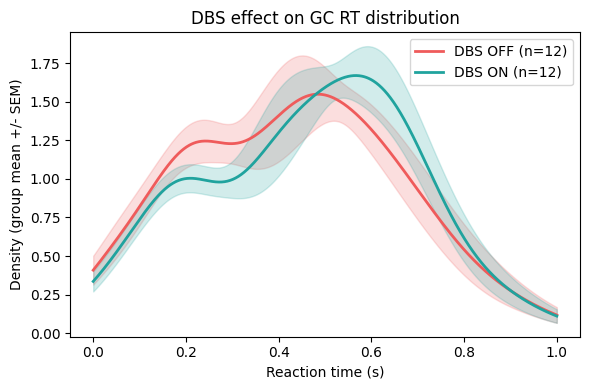

In [72]:
temp_save = os.path.join(behav_results_saving_path, "RT distribution")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)
# Figure 1b
plot_grand_average_kde(
    stats = stats, 
    trial_type='GC',
    color_dict = color_dict,
    x_range = (0, 1),
    n_points = 1000,
    rt_key_map = {
        'GC': 'GC RTs from continue cue (ms)',
        'GS': 'GS RTs from stop cue (ms)',
        'GO': 'go_trial RTs (ms)',
        'GF': 'go_fast_trial RTs (ms)',
    },
    save_path = temp_save,
    save_as = save_as,
    title = 'DBS effect on GC RT distribution',
    show_plot = True
)

## 3.2. Single subject vizualization ##

### 3.2.1. Difference between DBS OFF and DBS ON ###

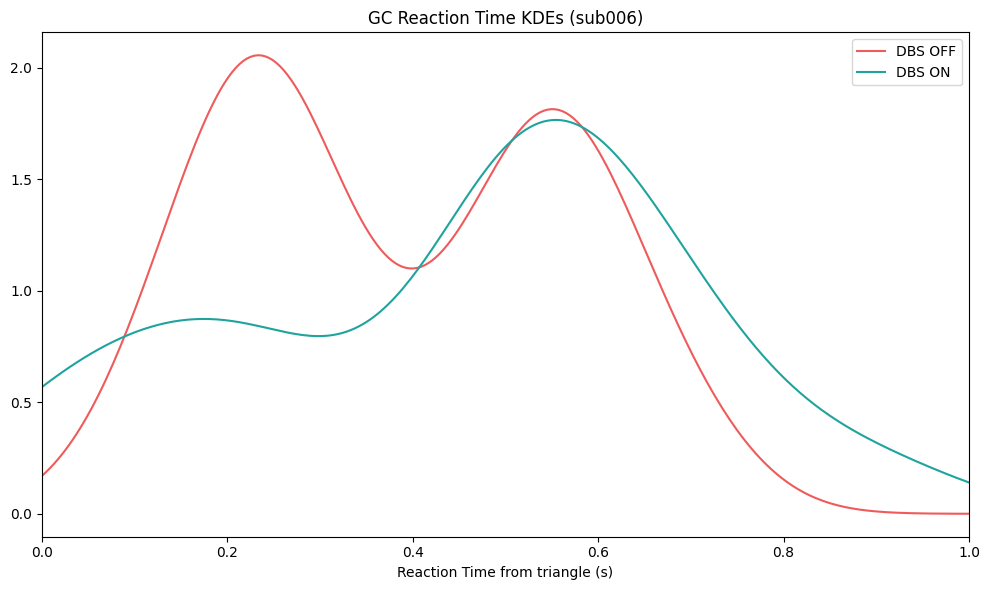

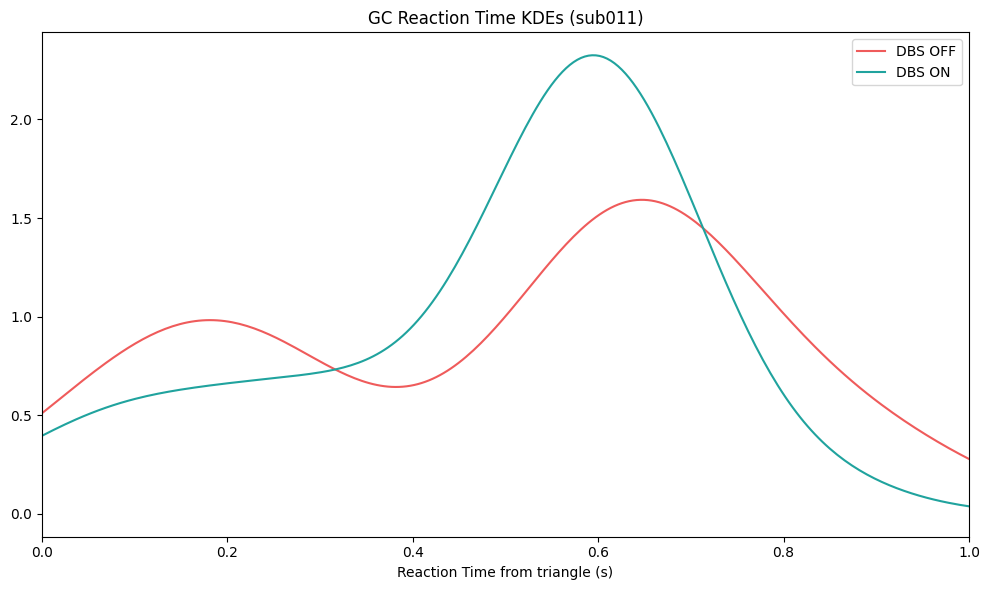

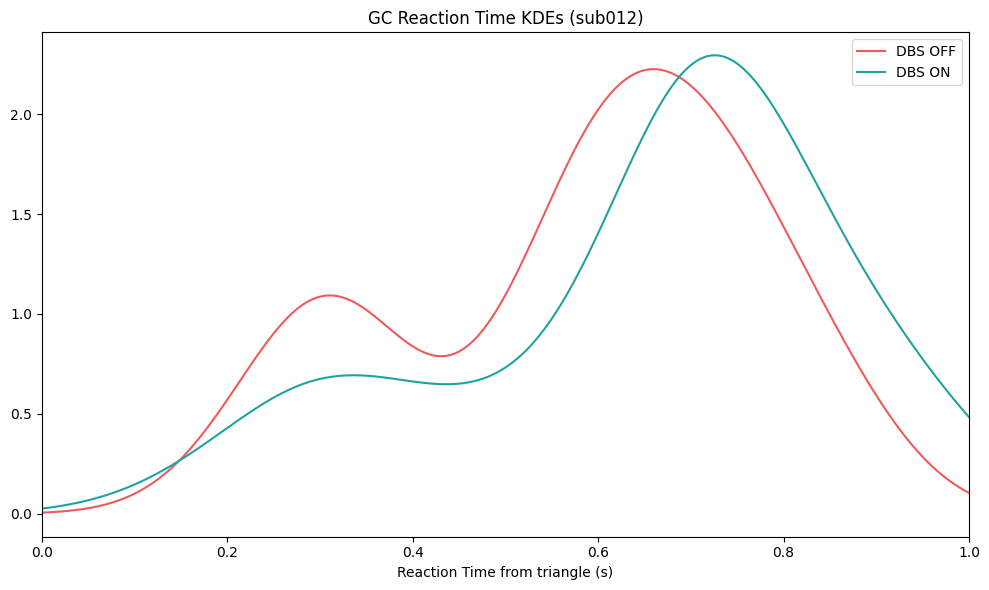

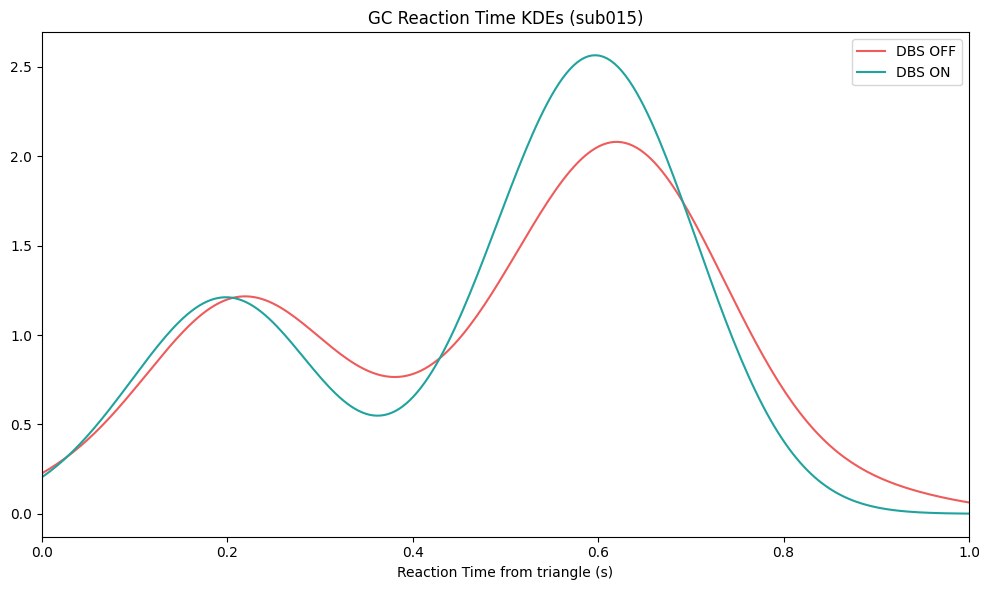

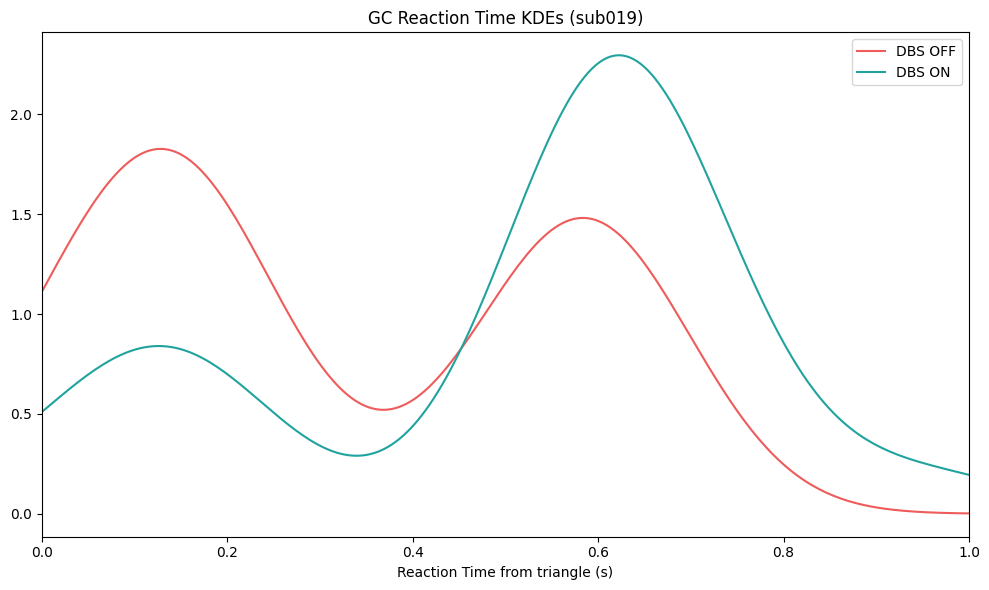

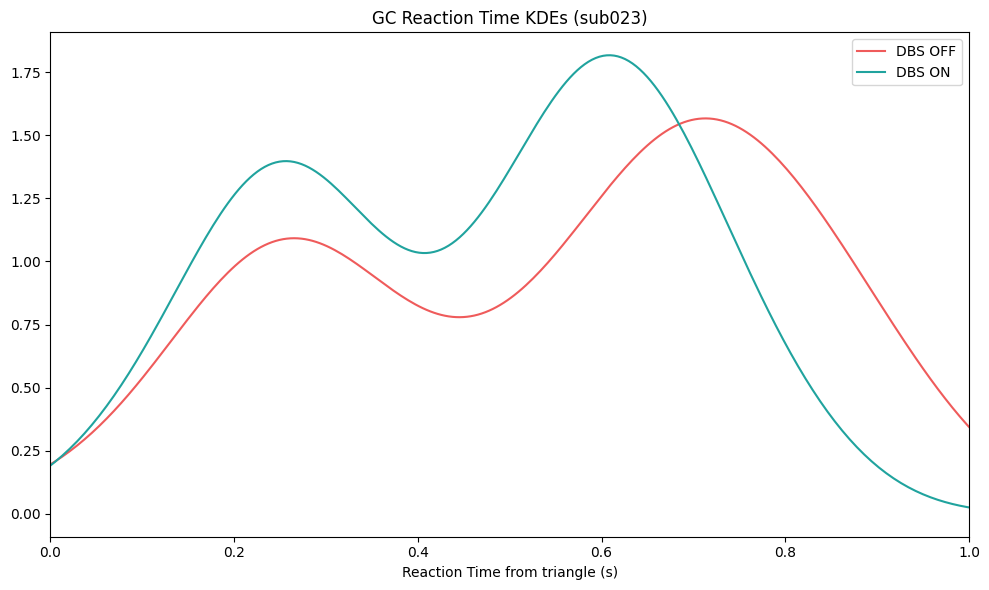

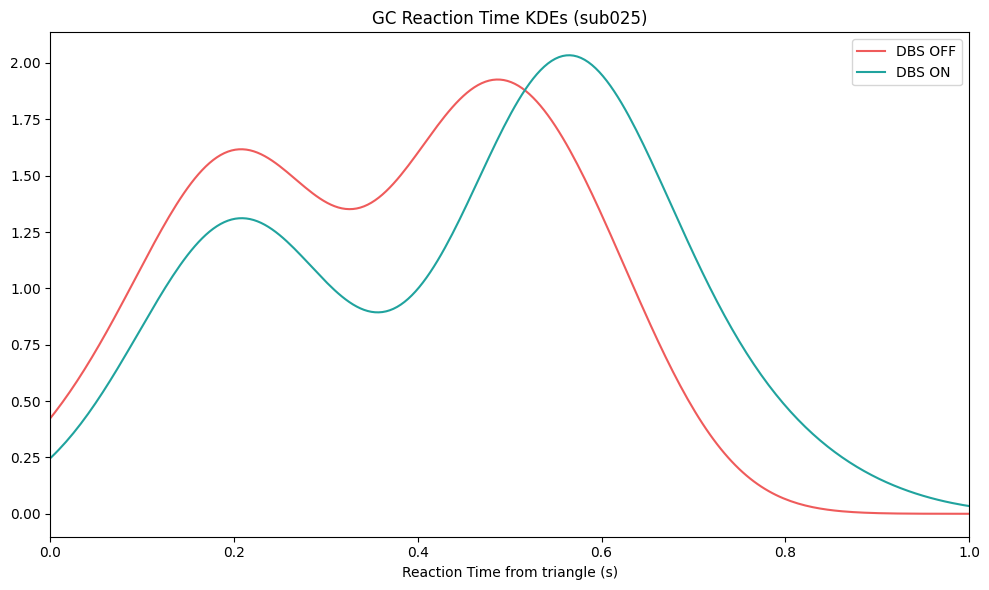

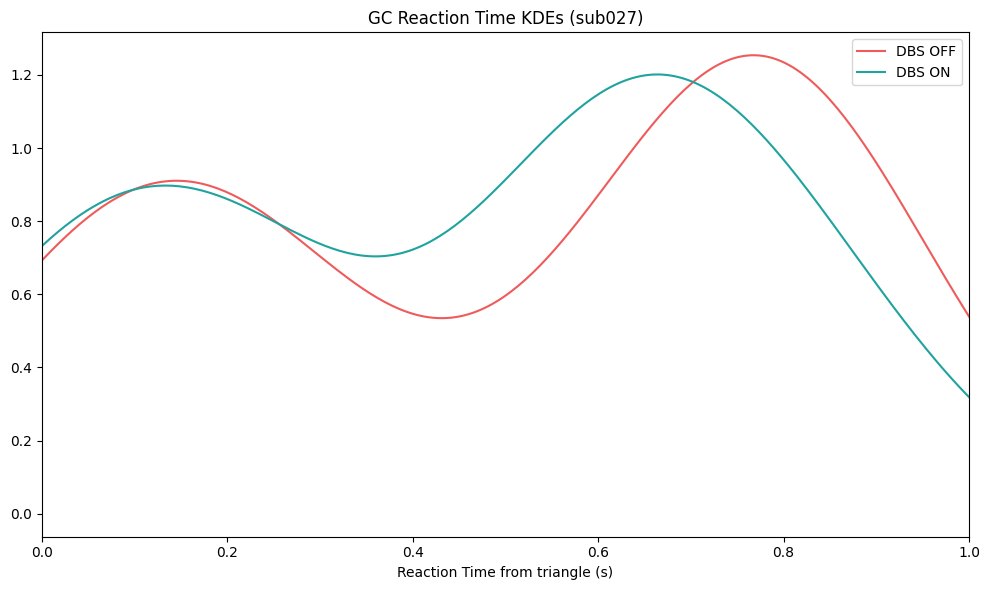

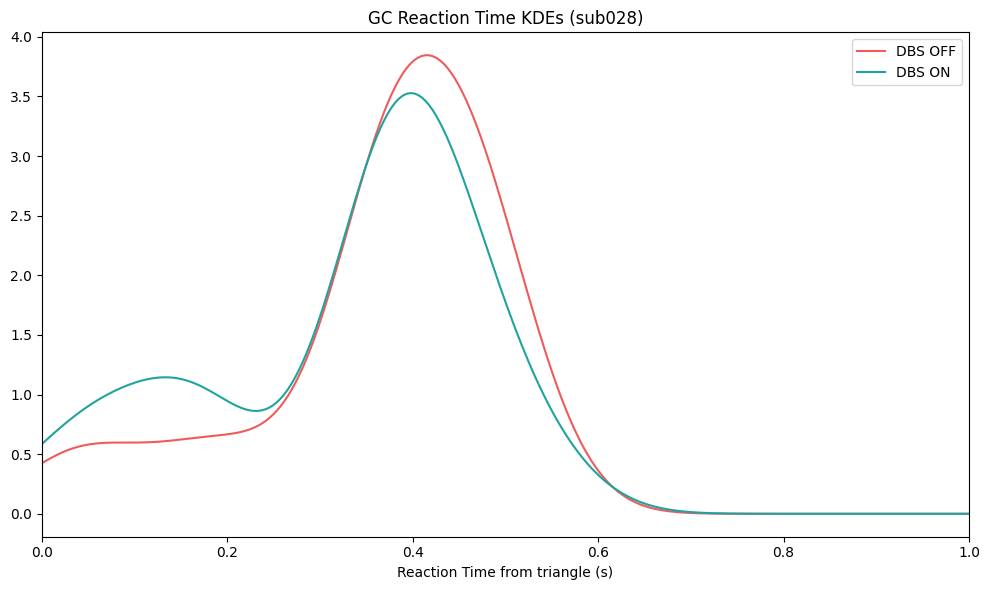

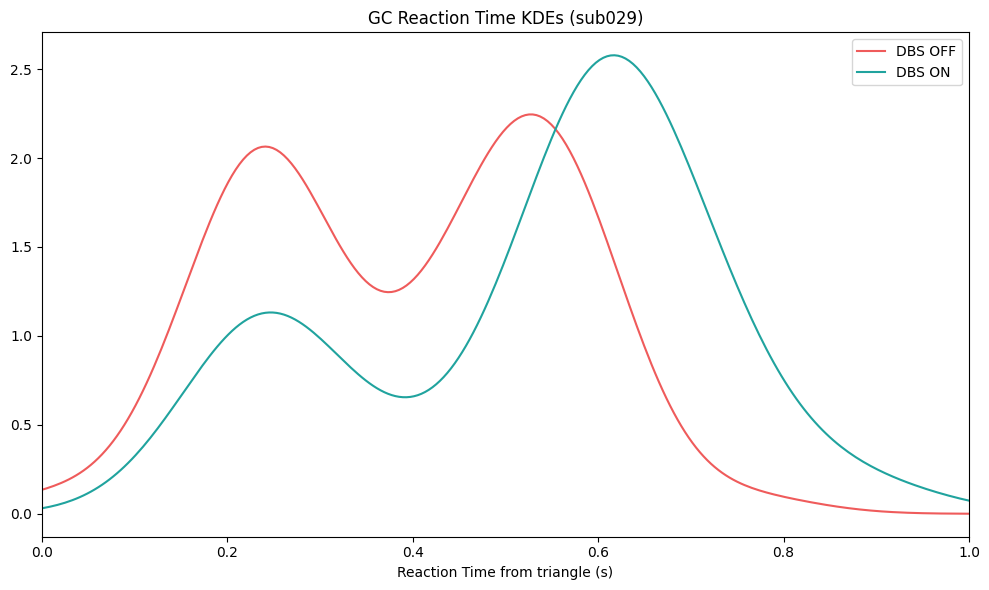

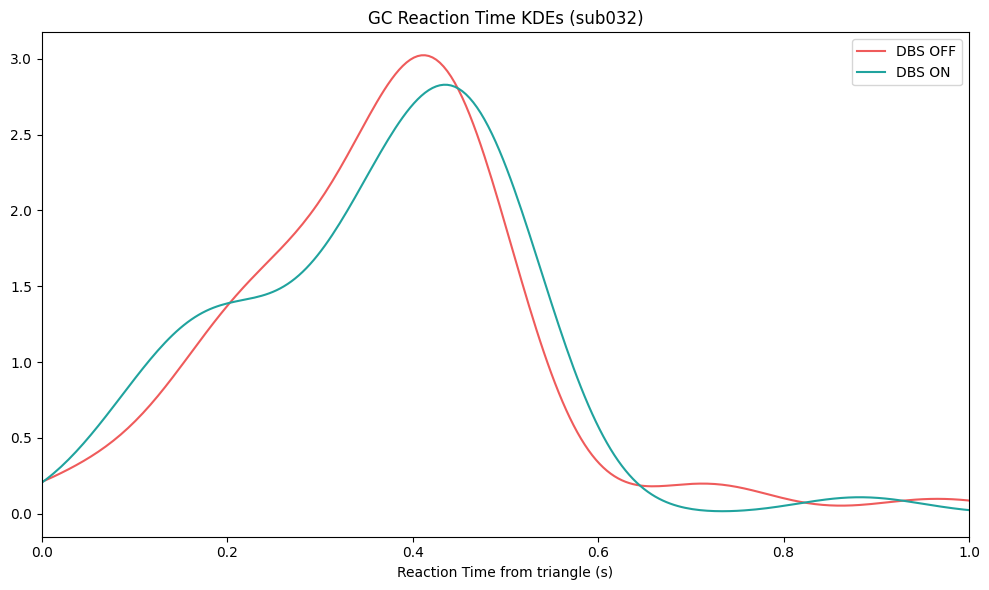

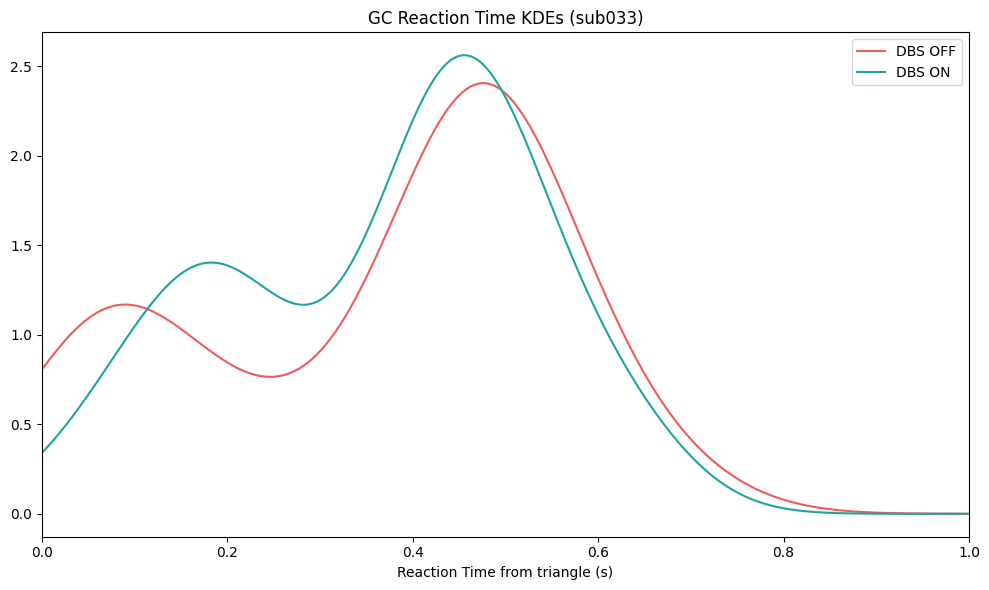

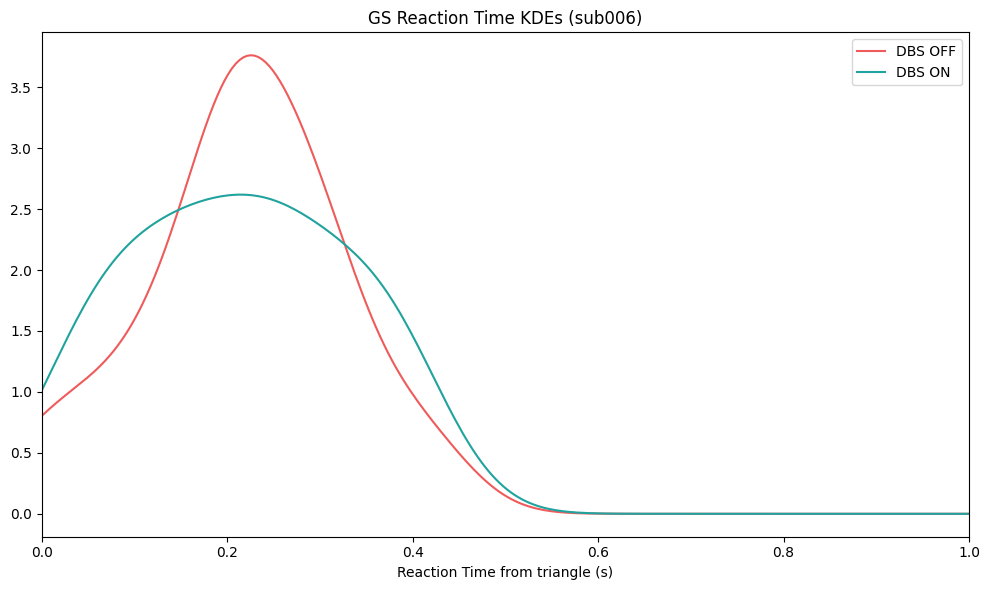

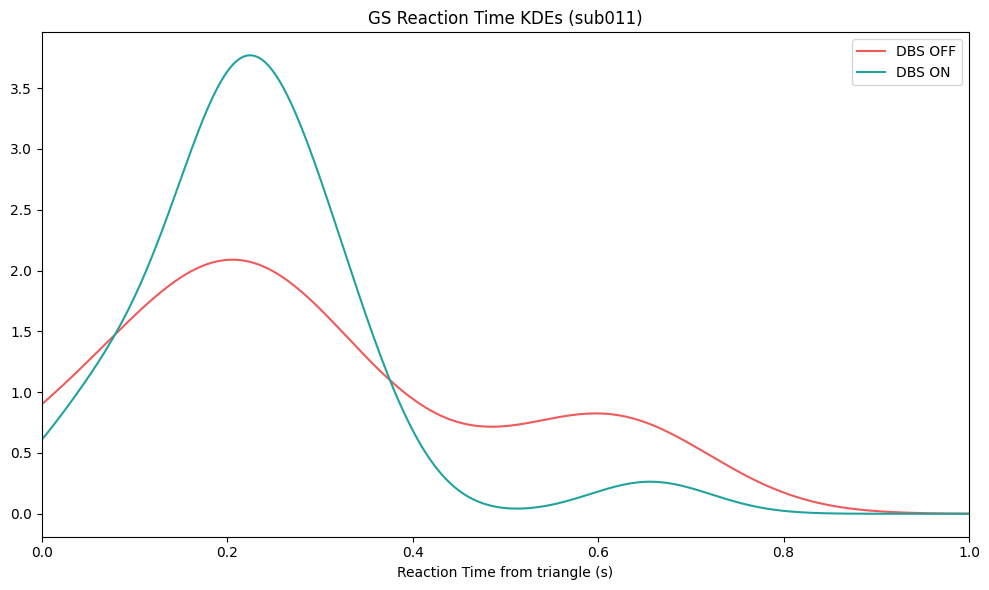

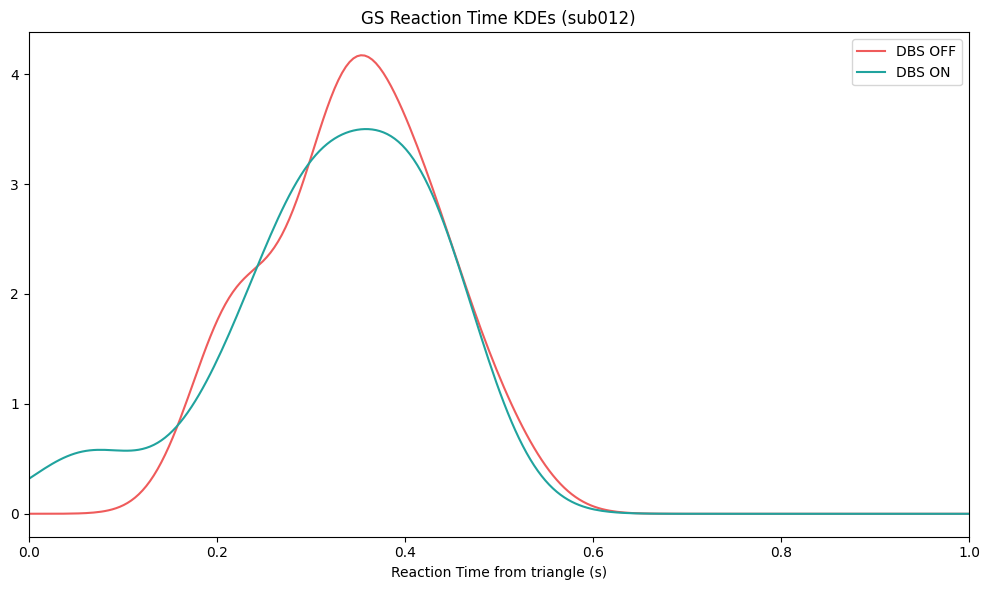

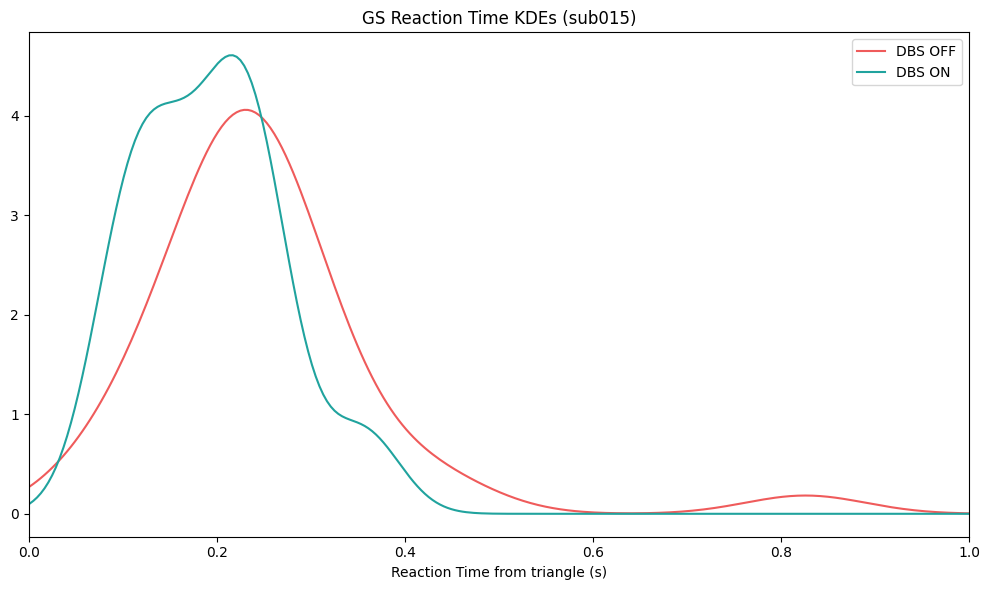

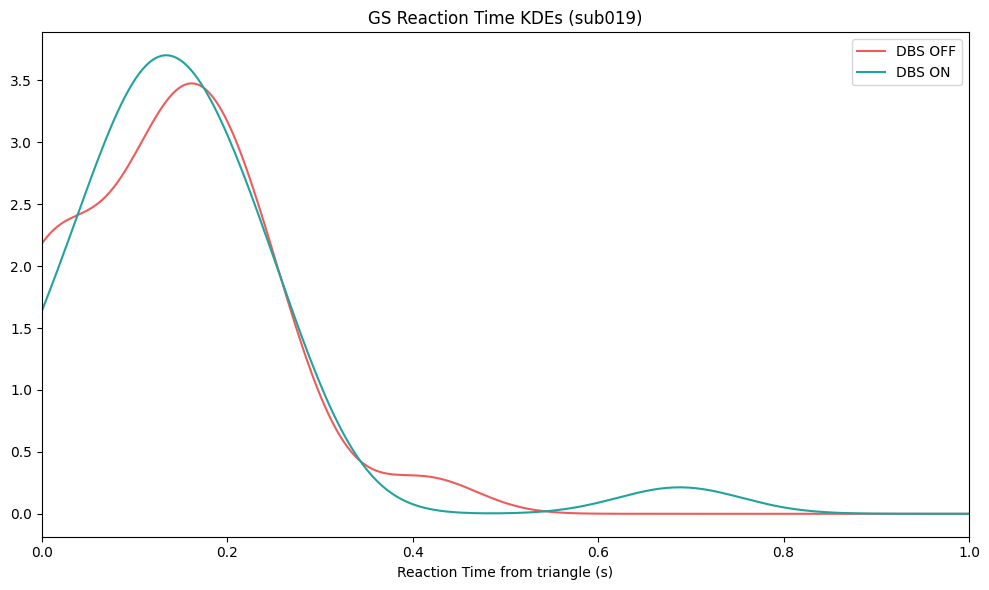

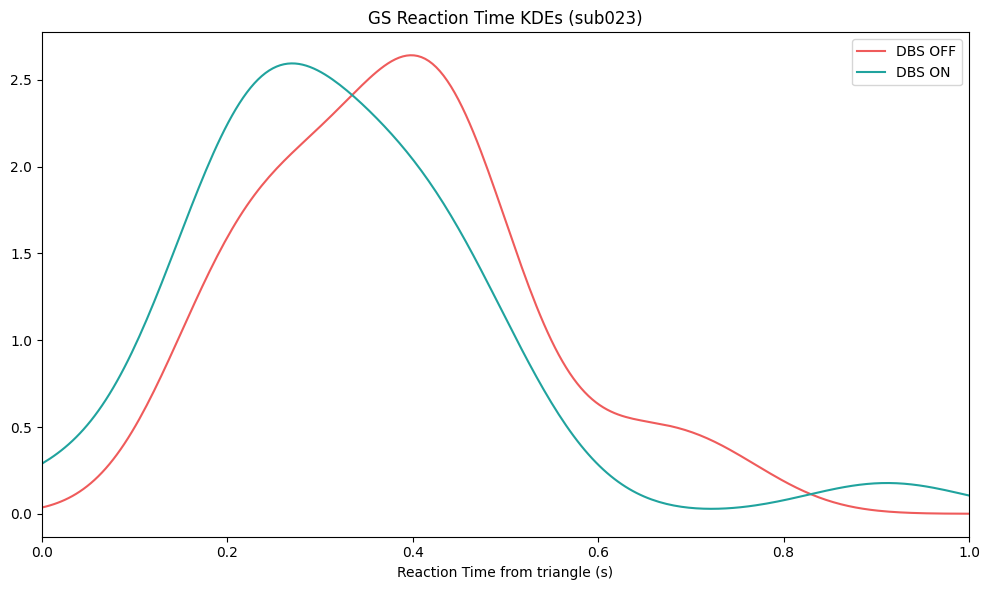

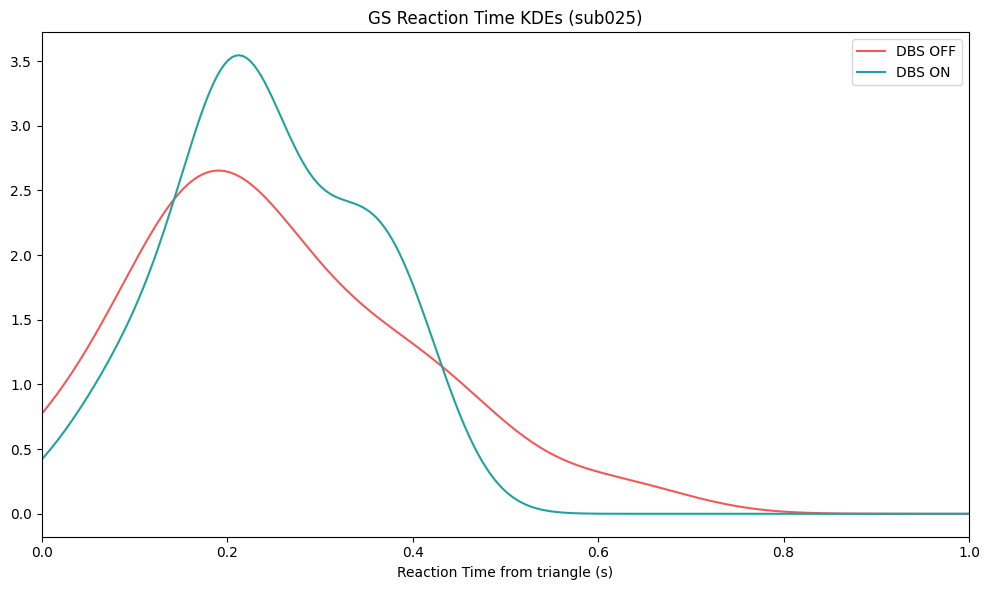

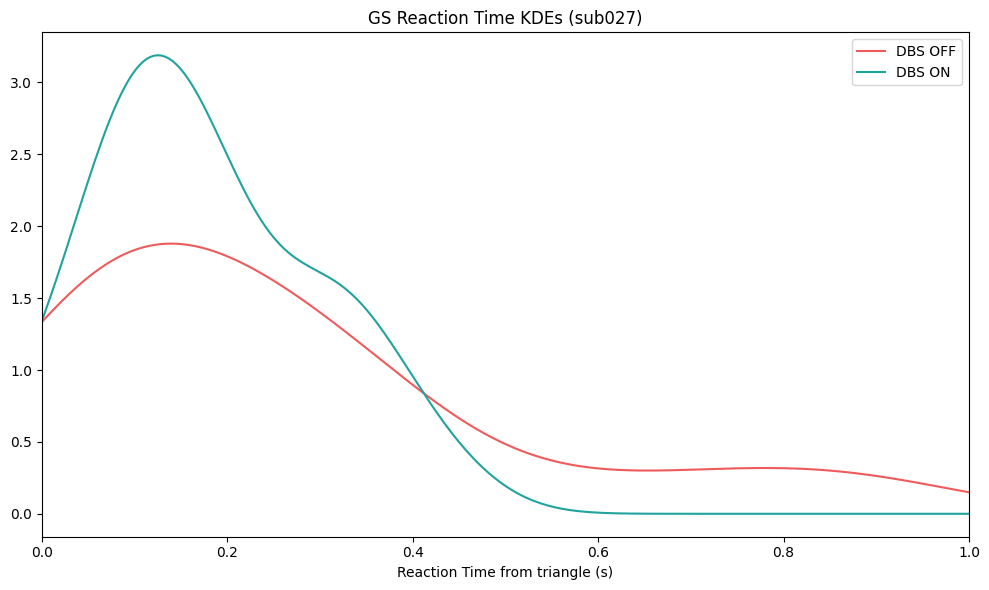

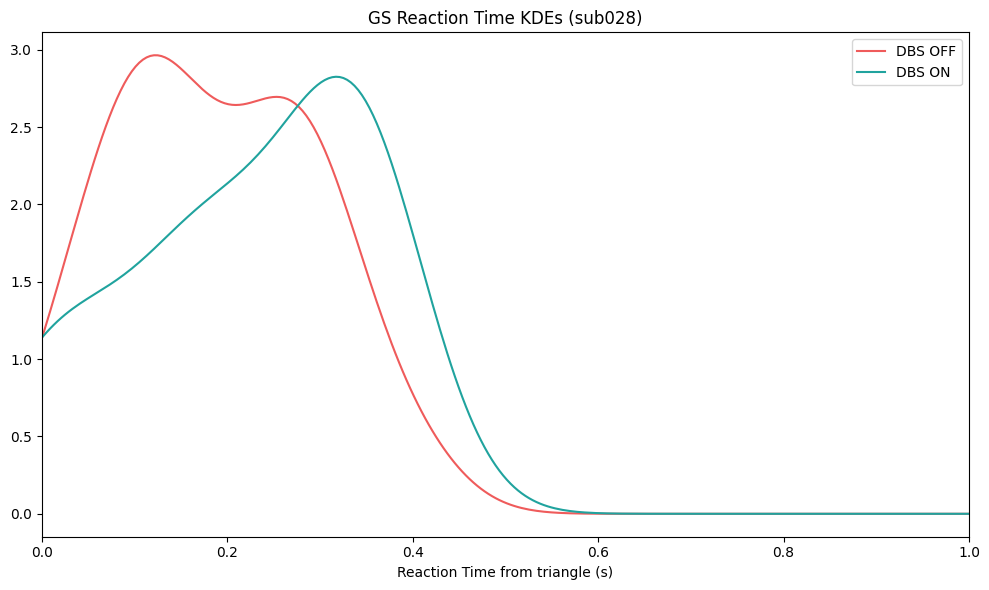

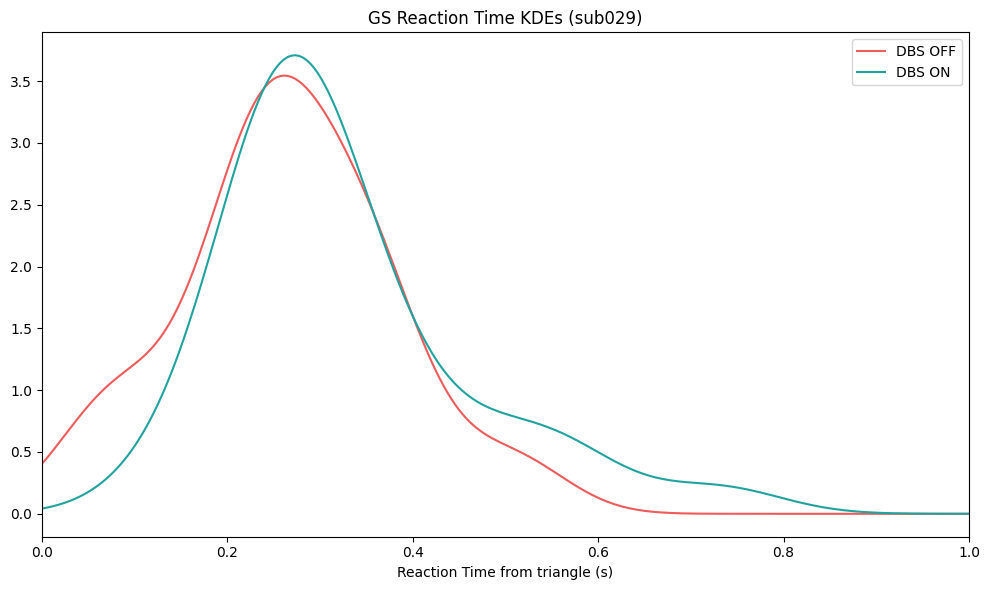

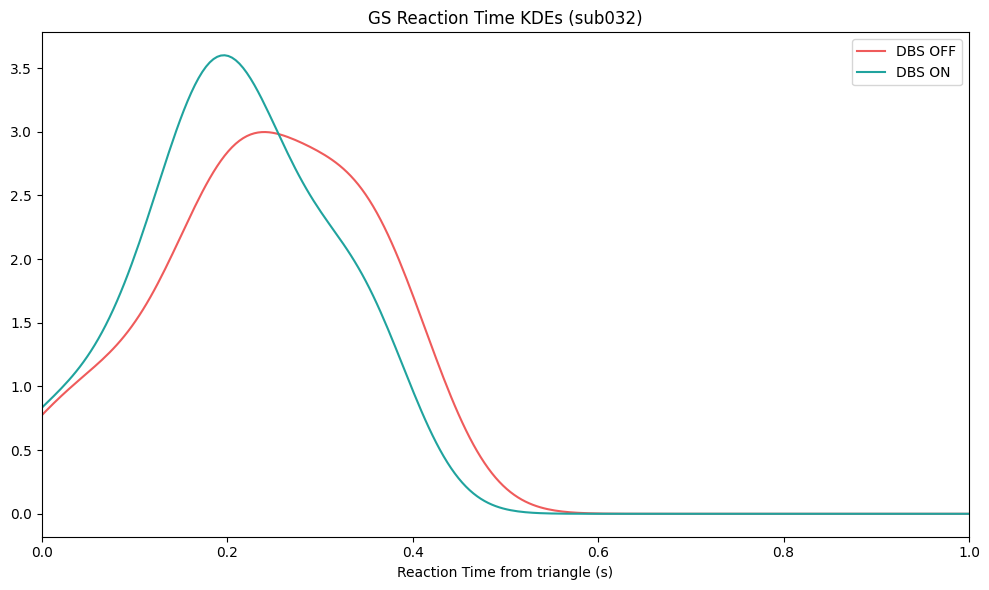

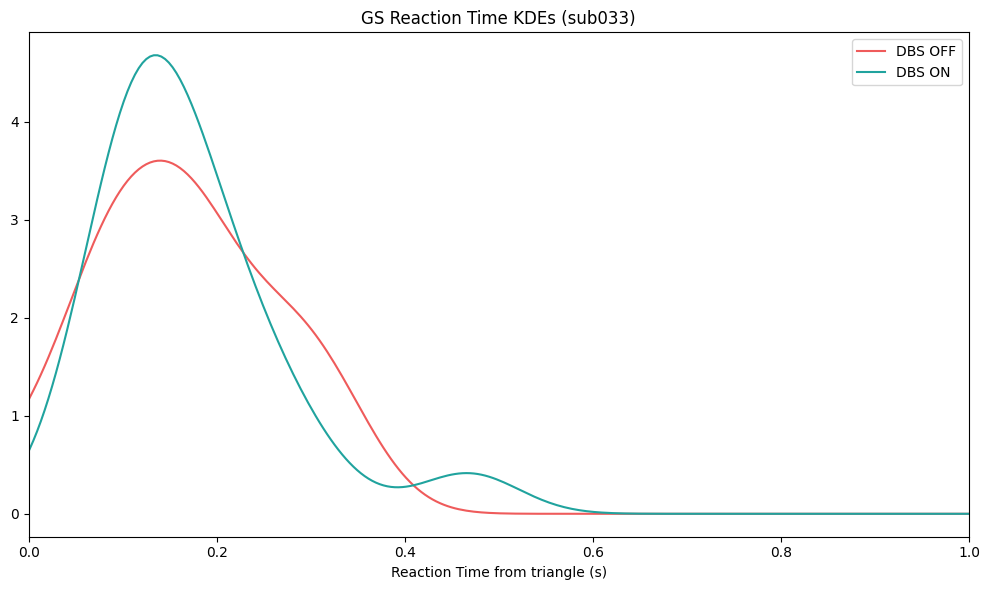

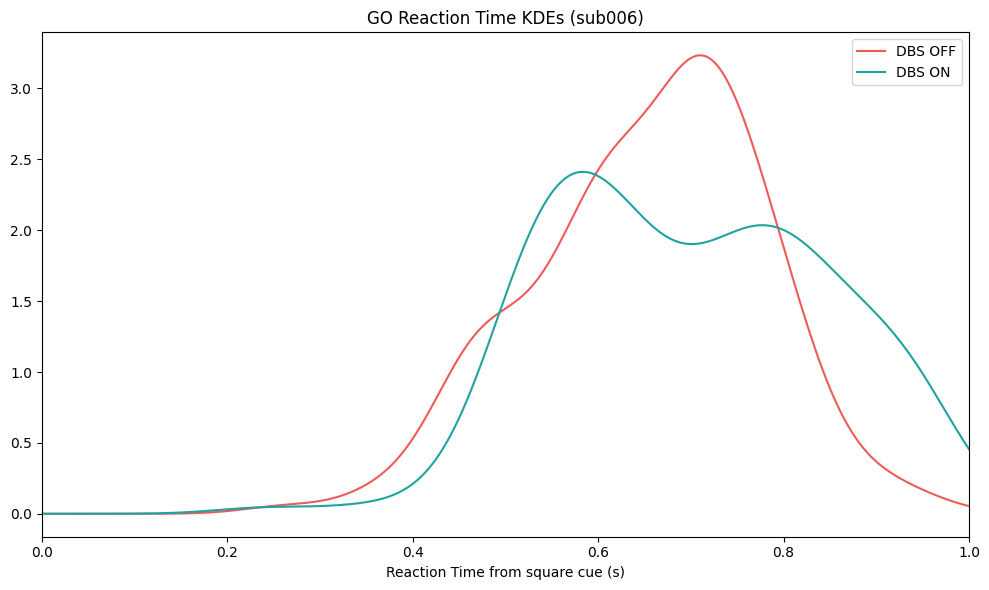

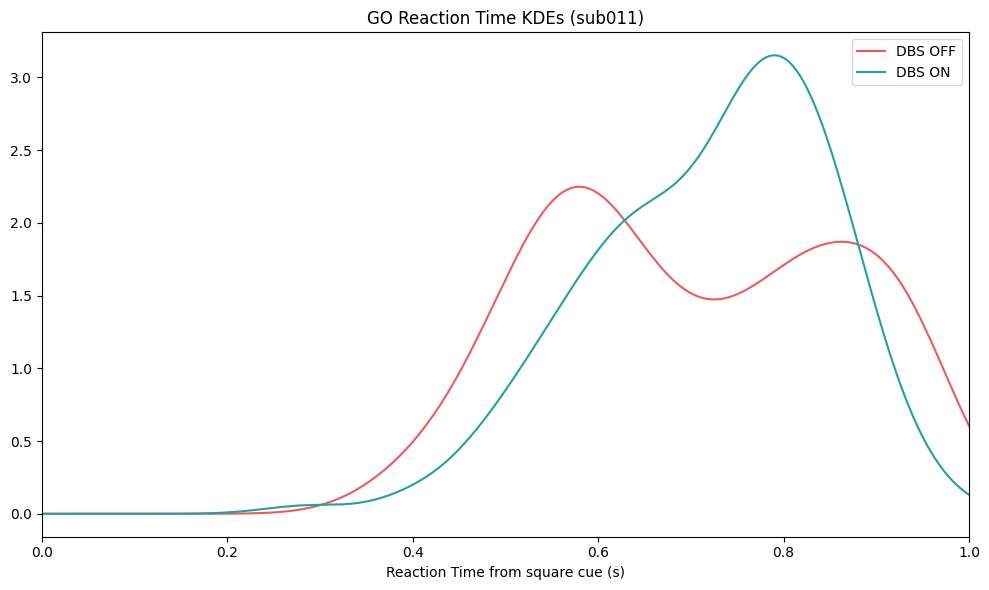

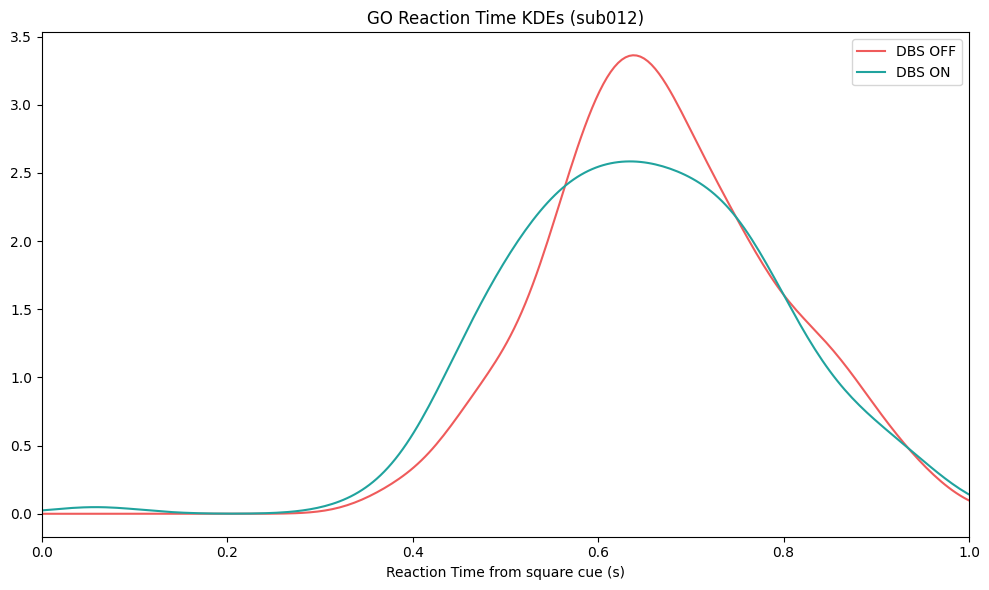

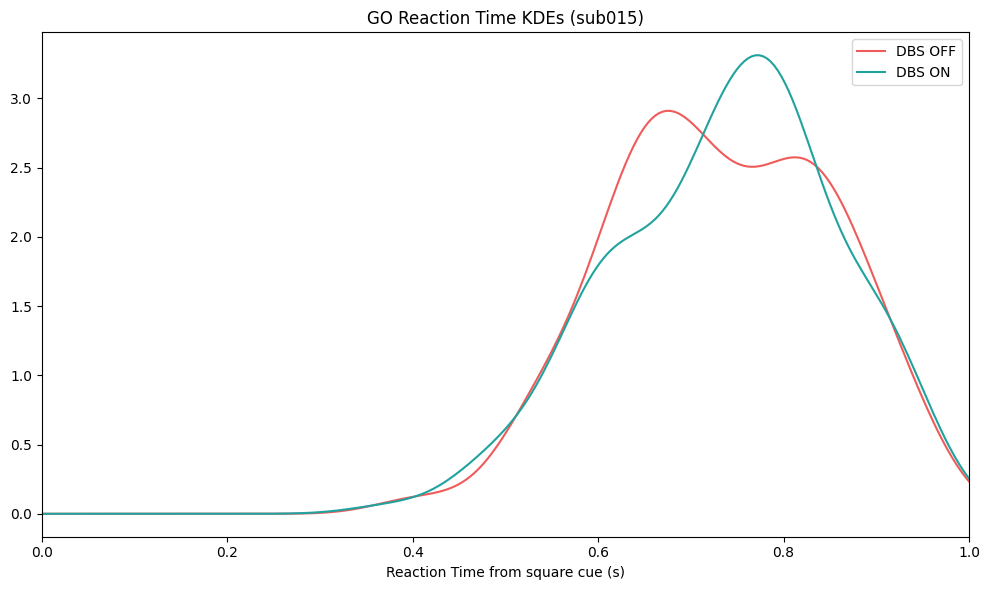

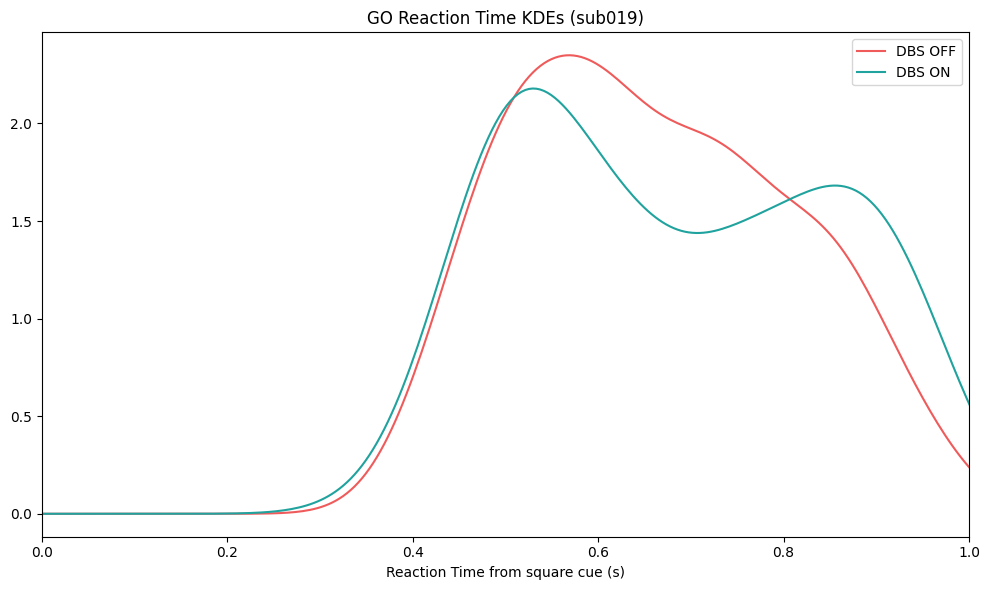

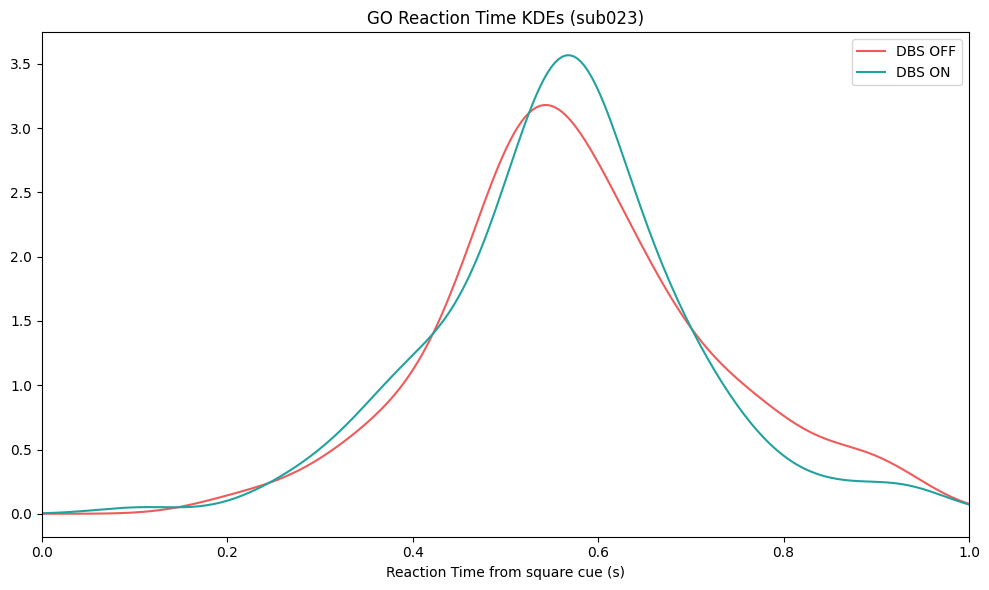

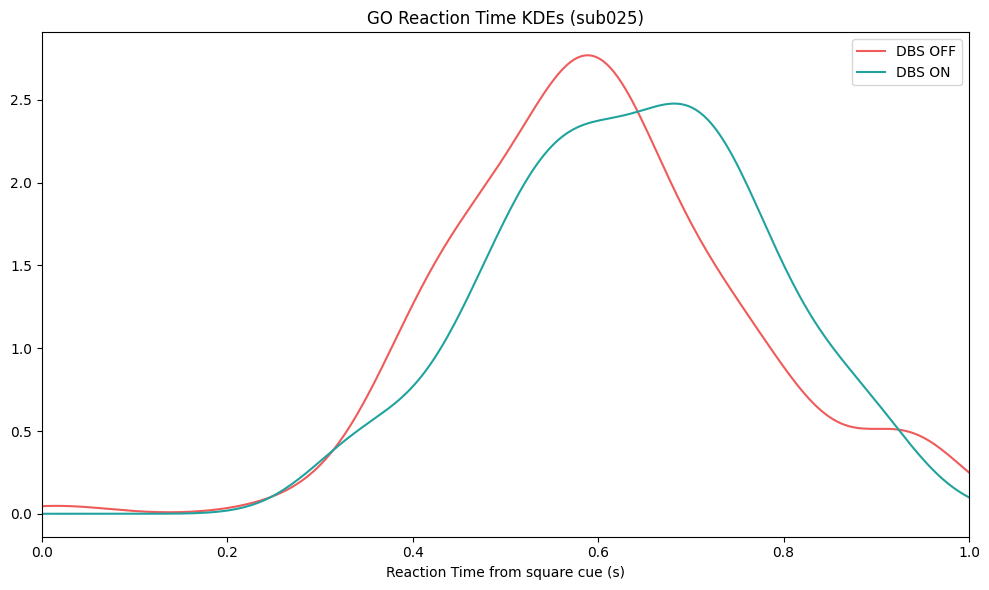

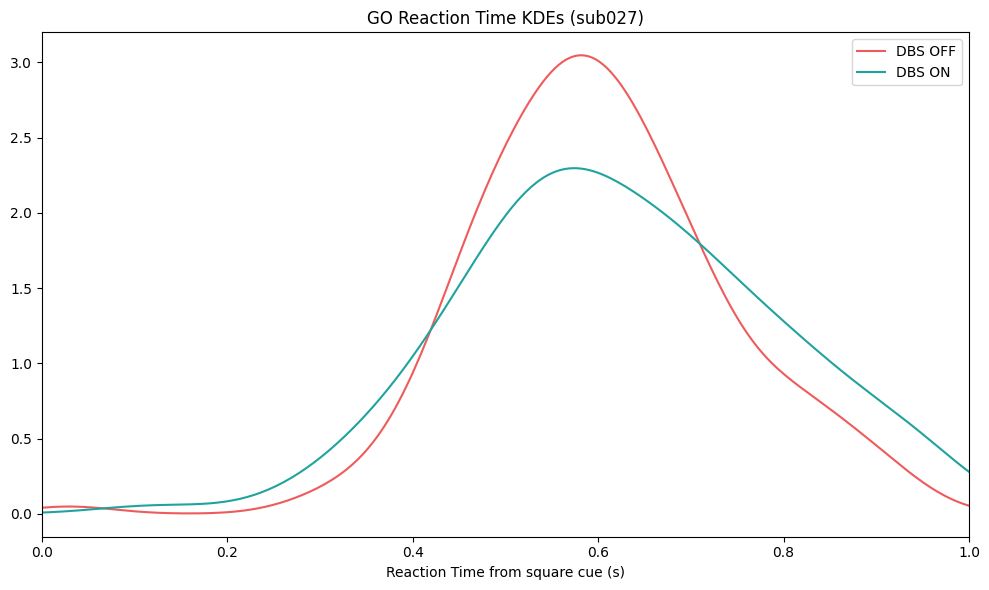

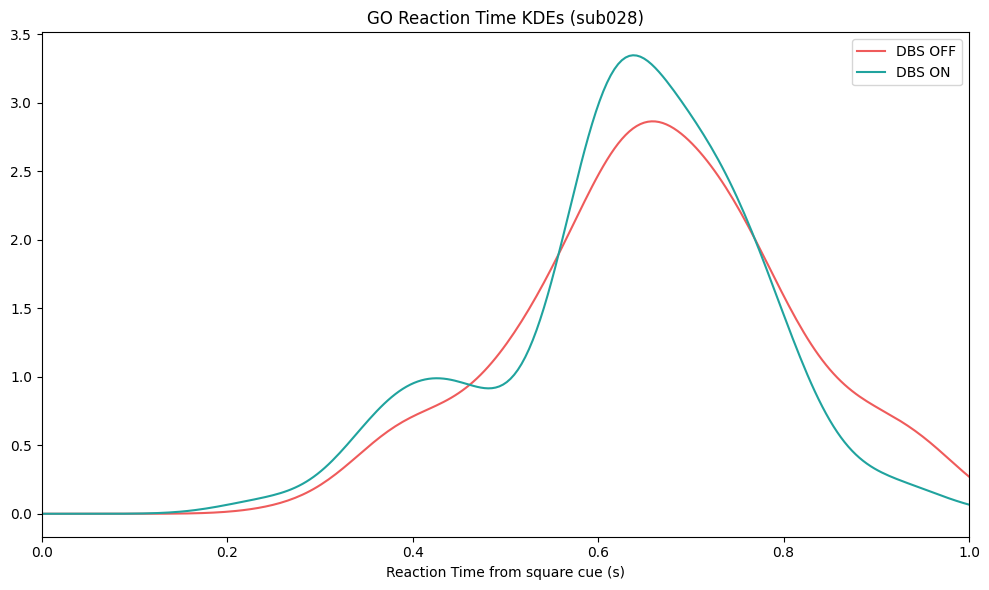

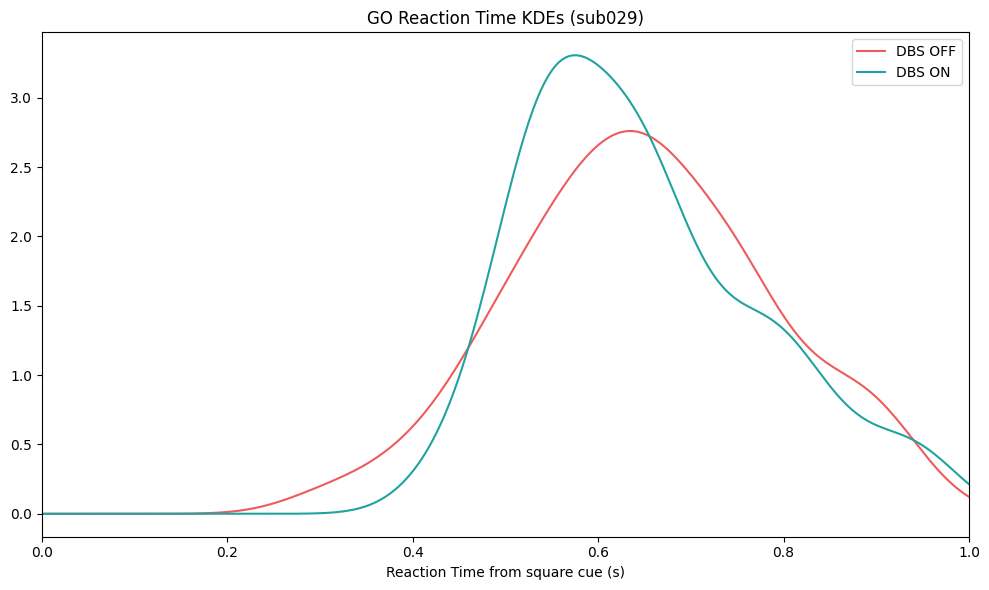

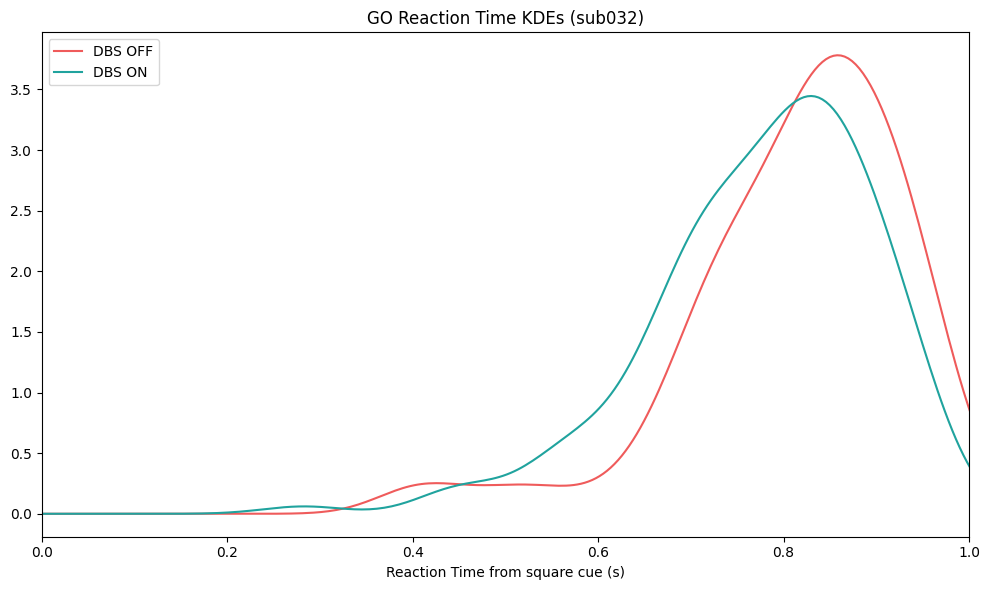

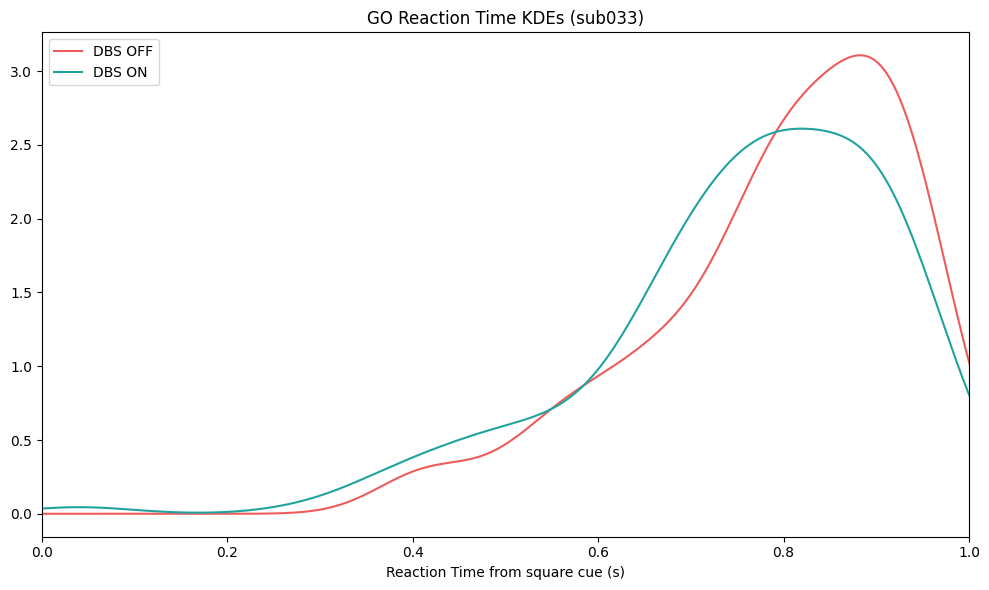

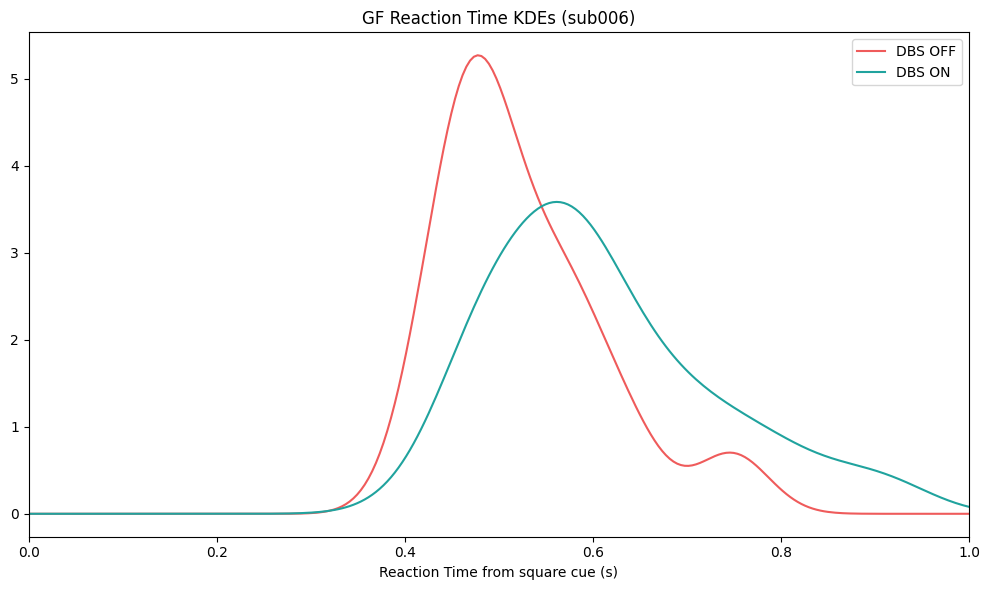

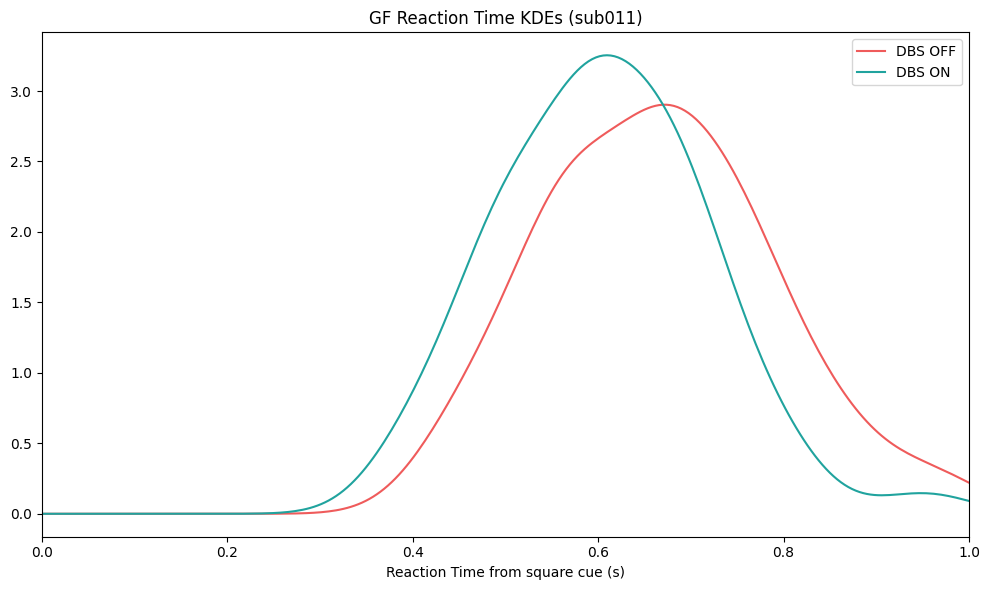

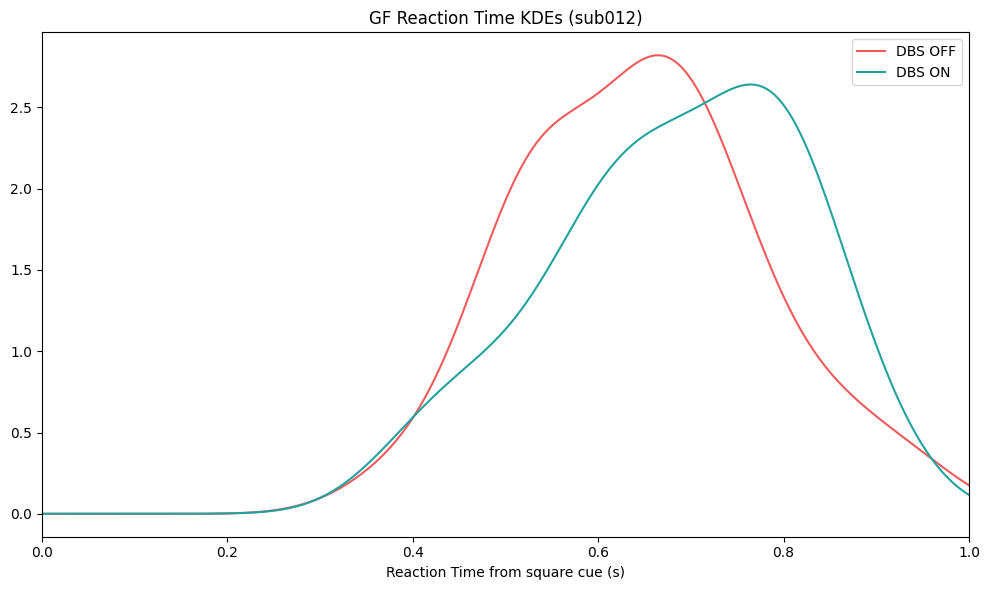

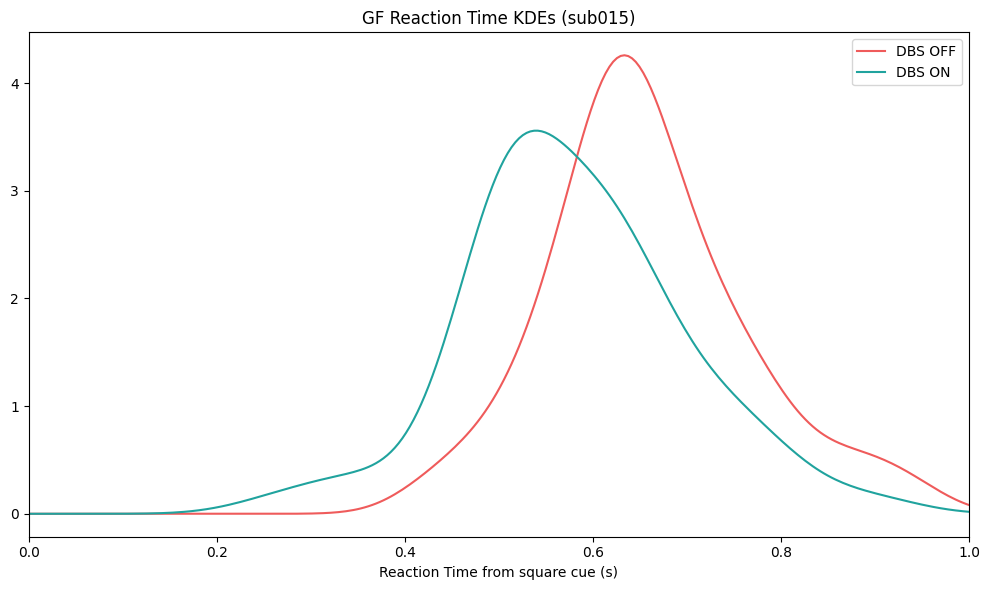

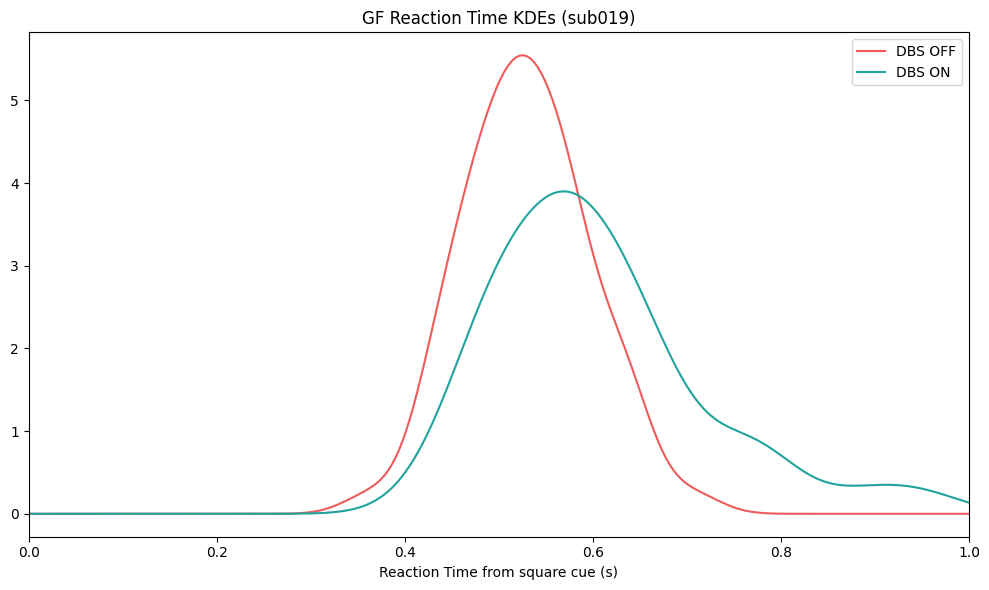

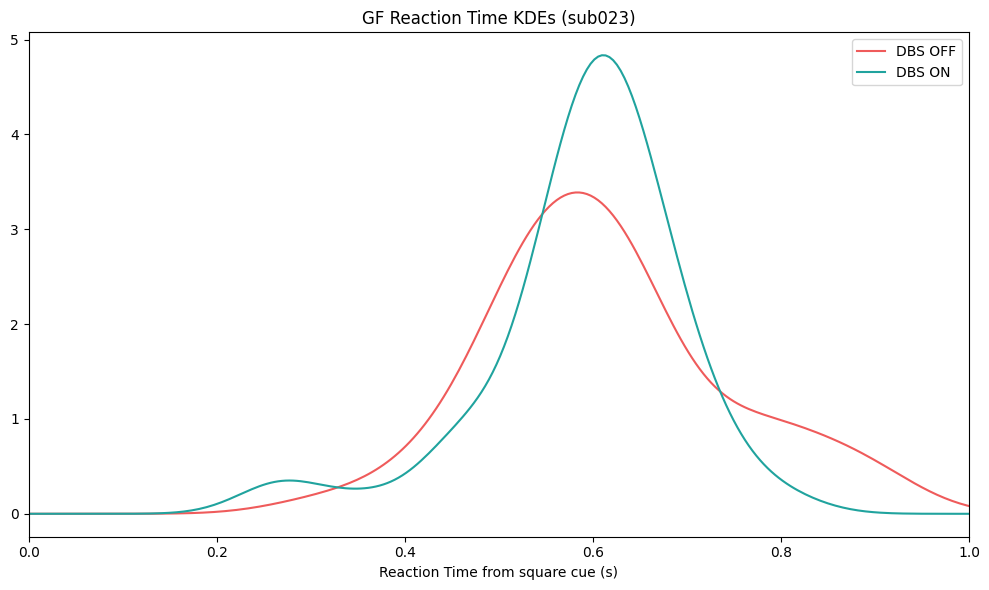

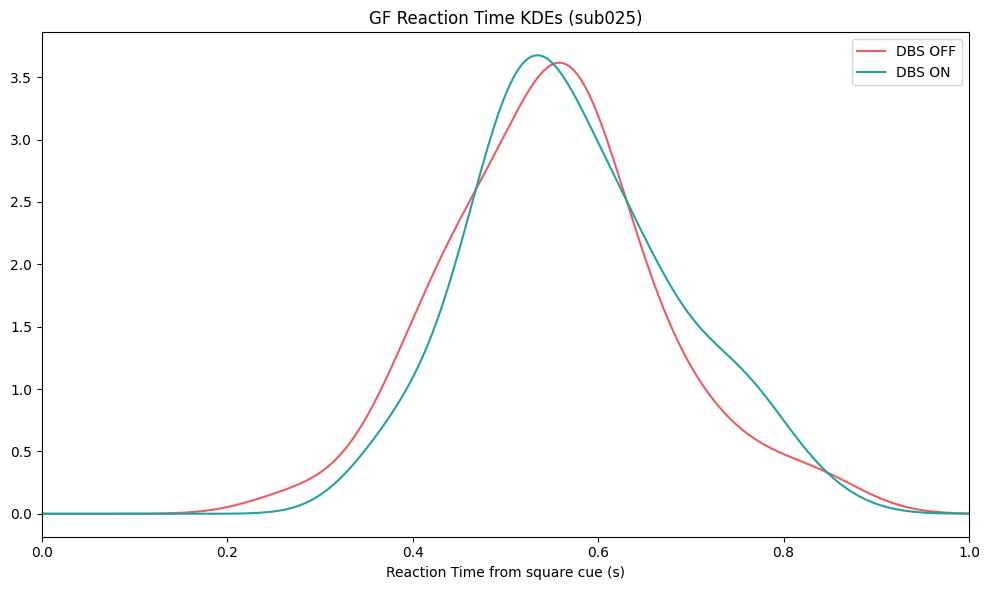

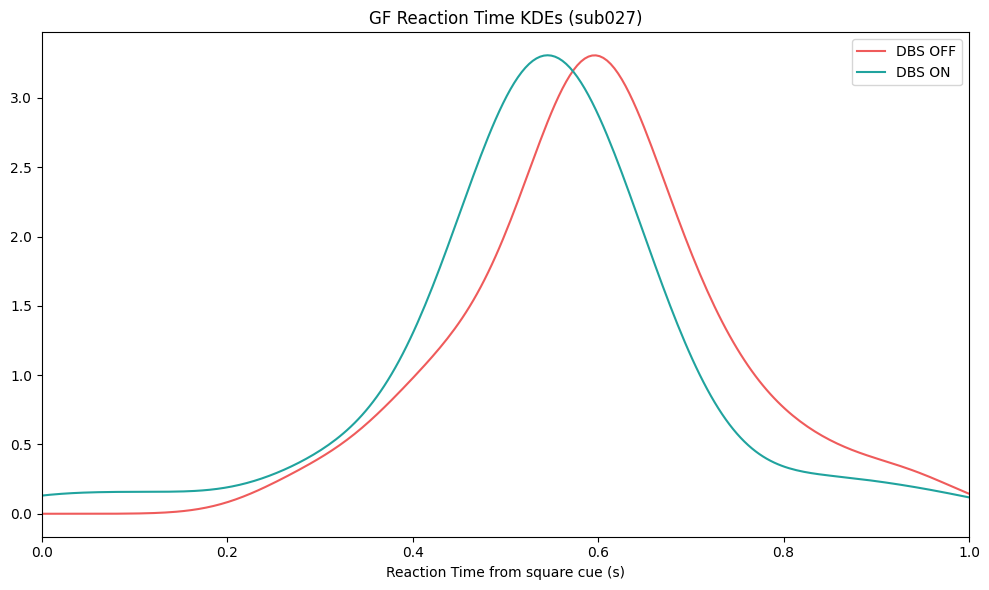

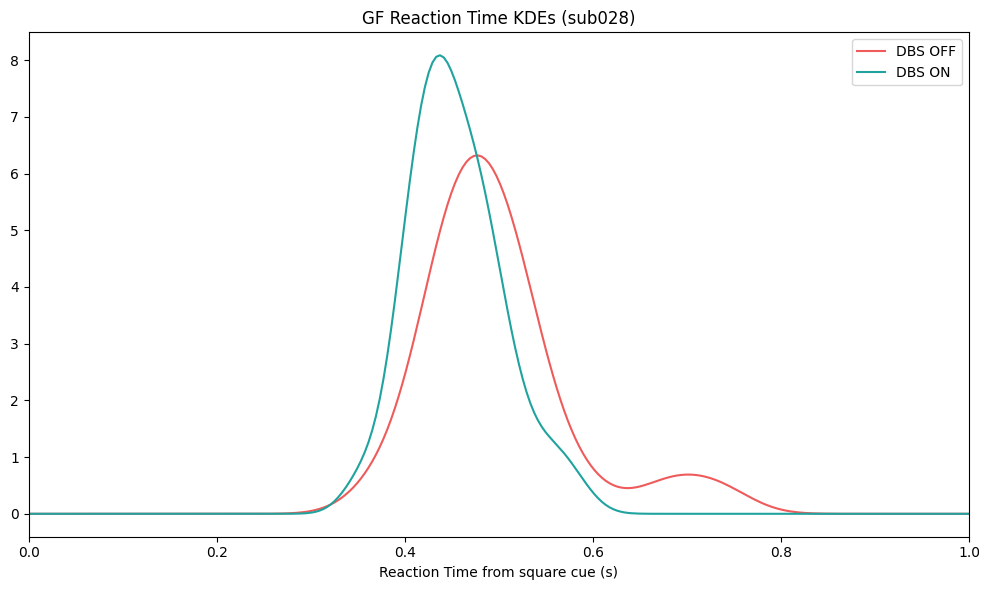

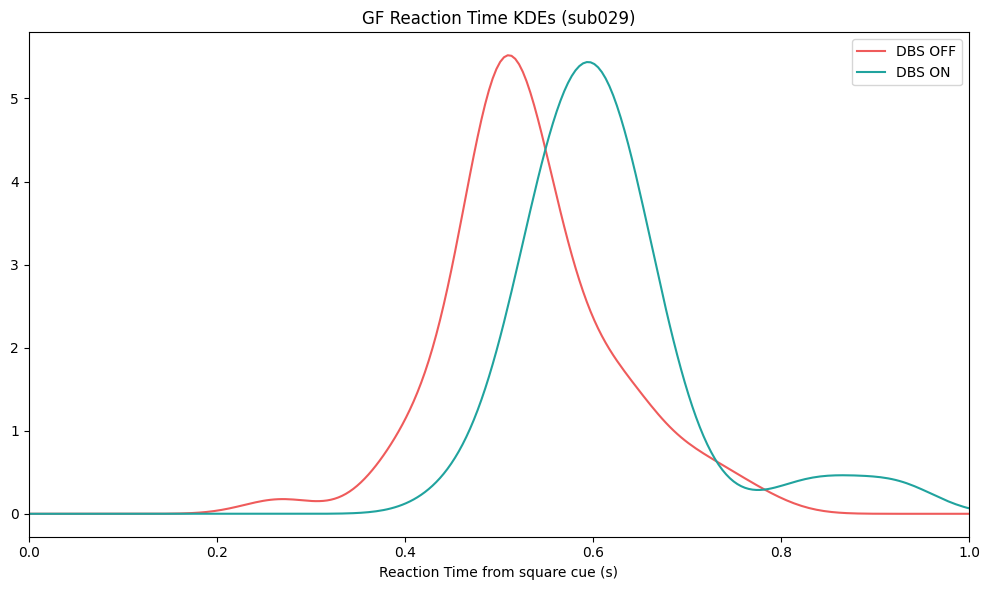

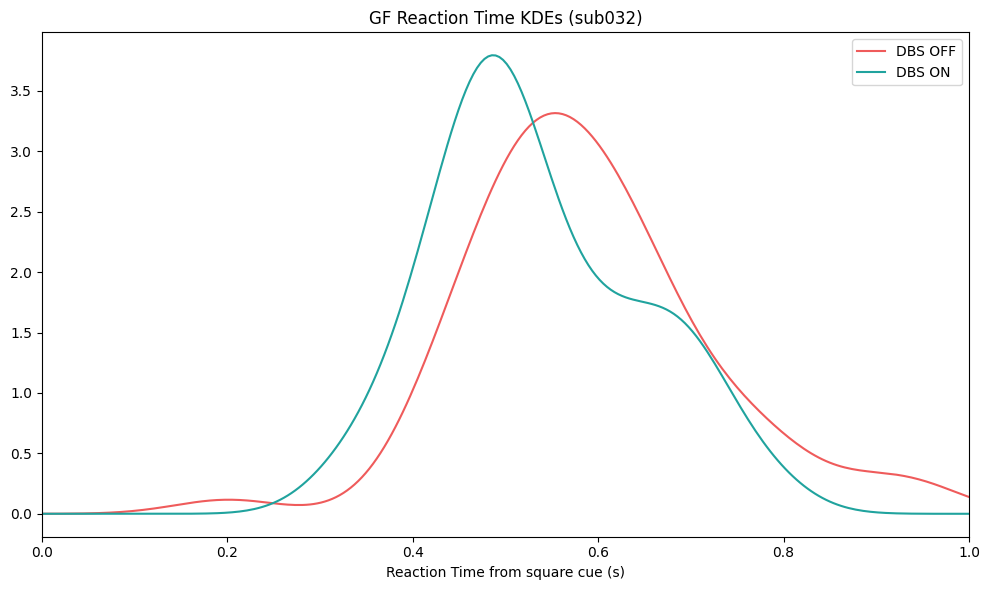

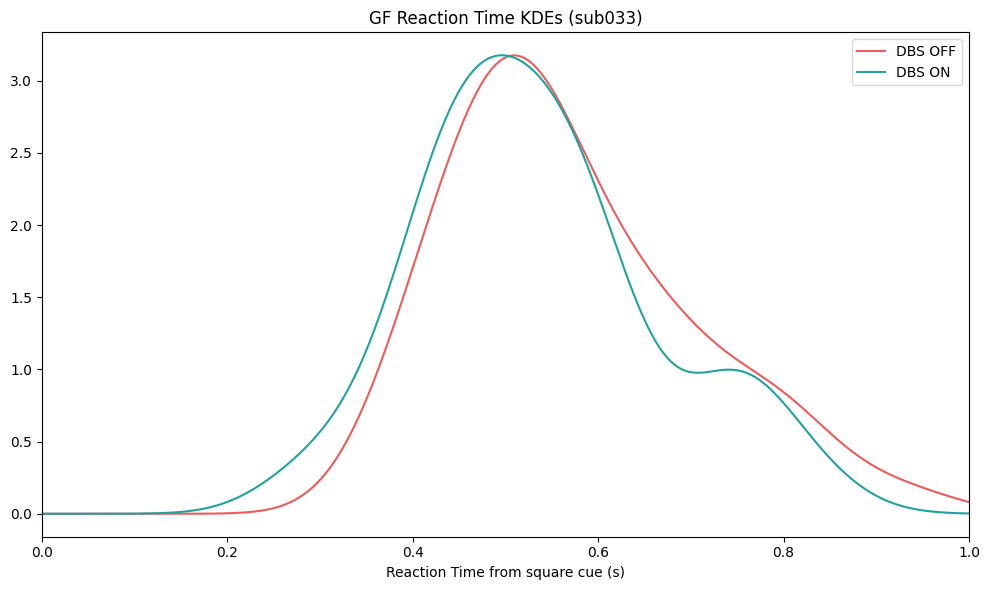

In [11]:
temp_save = join(behav_results_saving_path, "RT distribution", "single sub", "ON versus OFF")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)
behav_analysis.plot_kde_on_off_per_trial_type(
        stats, 
        color_dict, 
        save_path=temp_save, 
        save_as='png',
        show_plot = True)


### 3.2.2. Difference between trial types ###

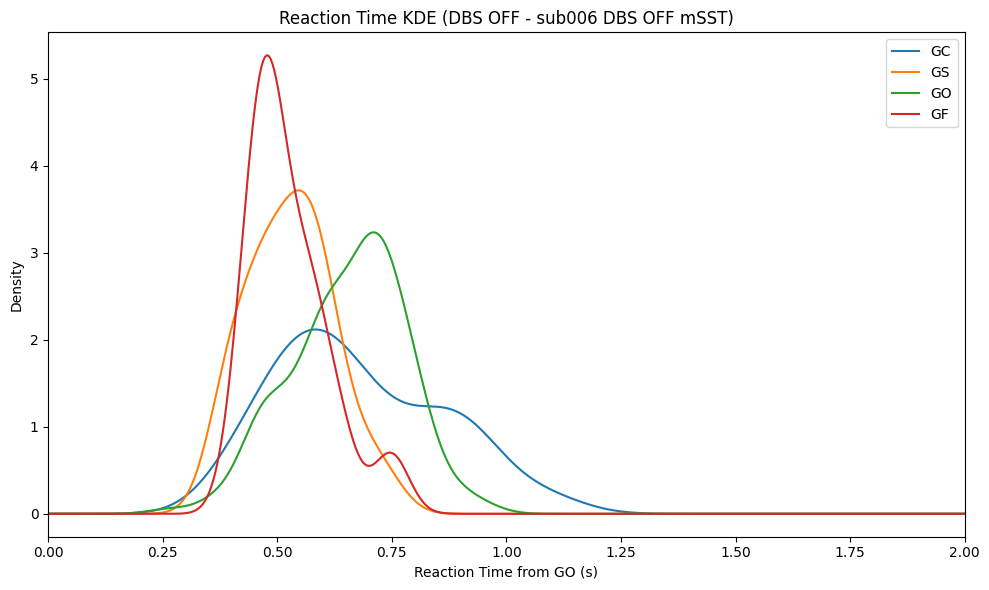

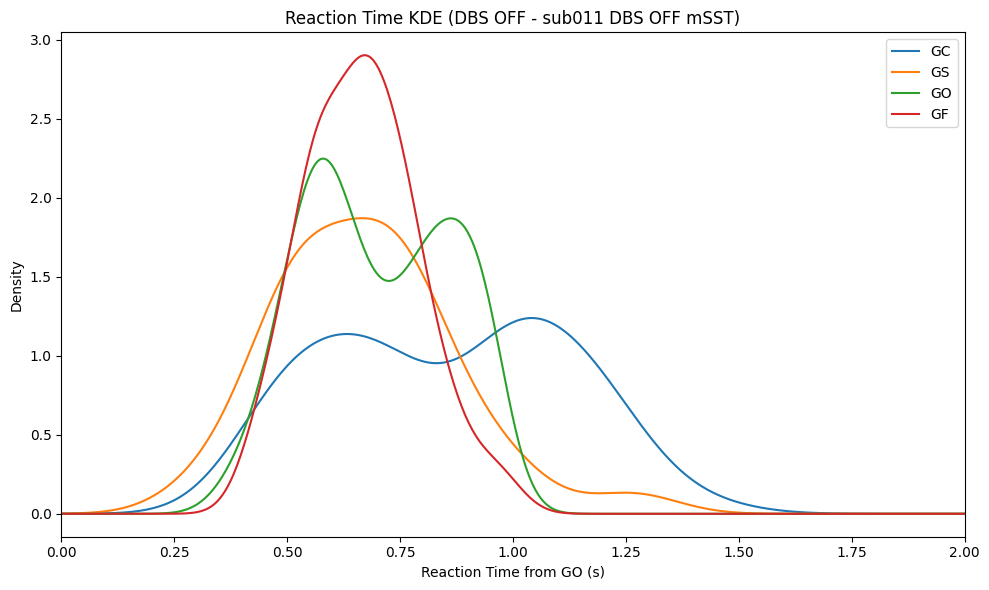

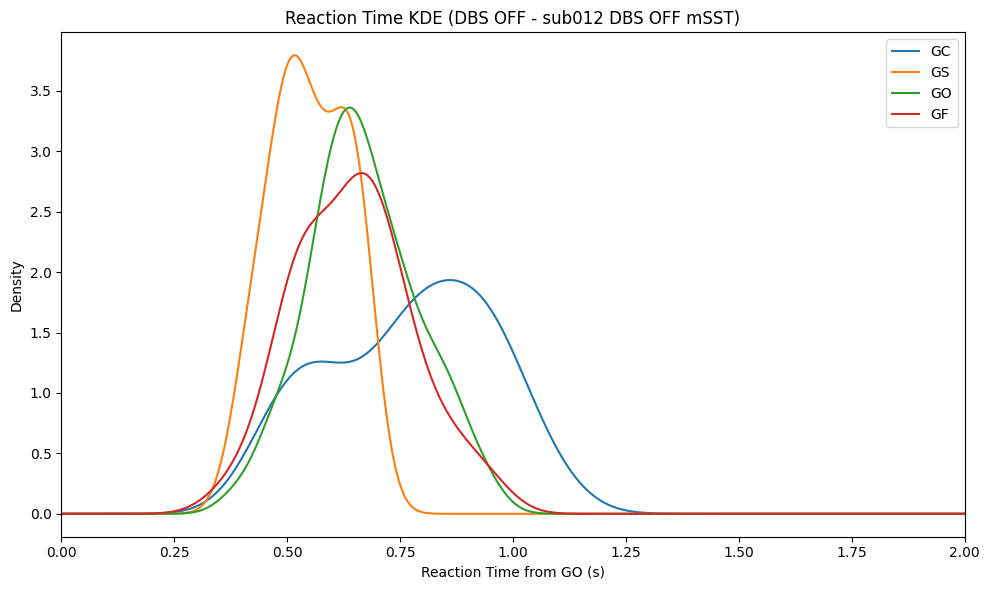

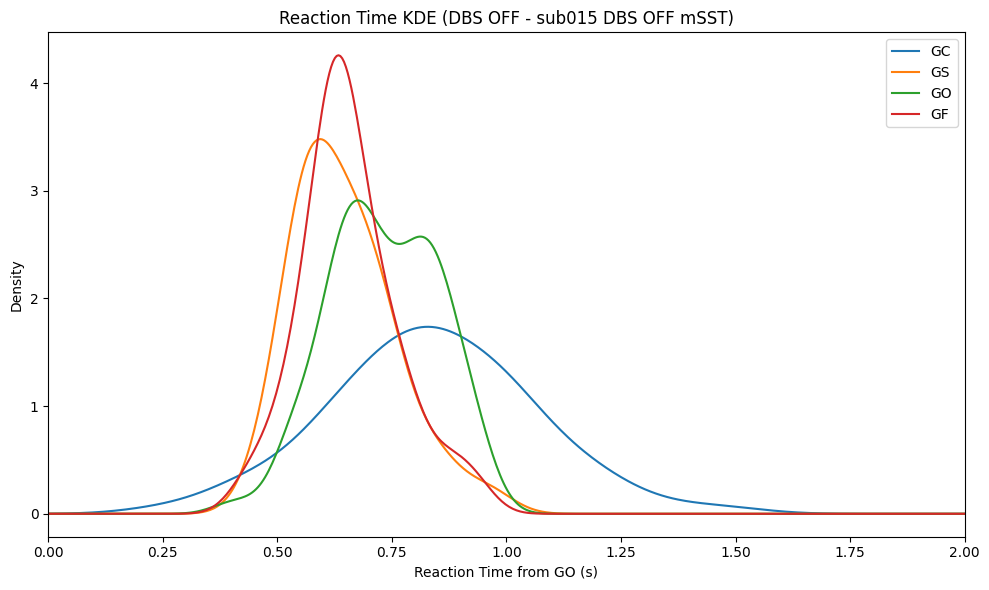

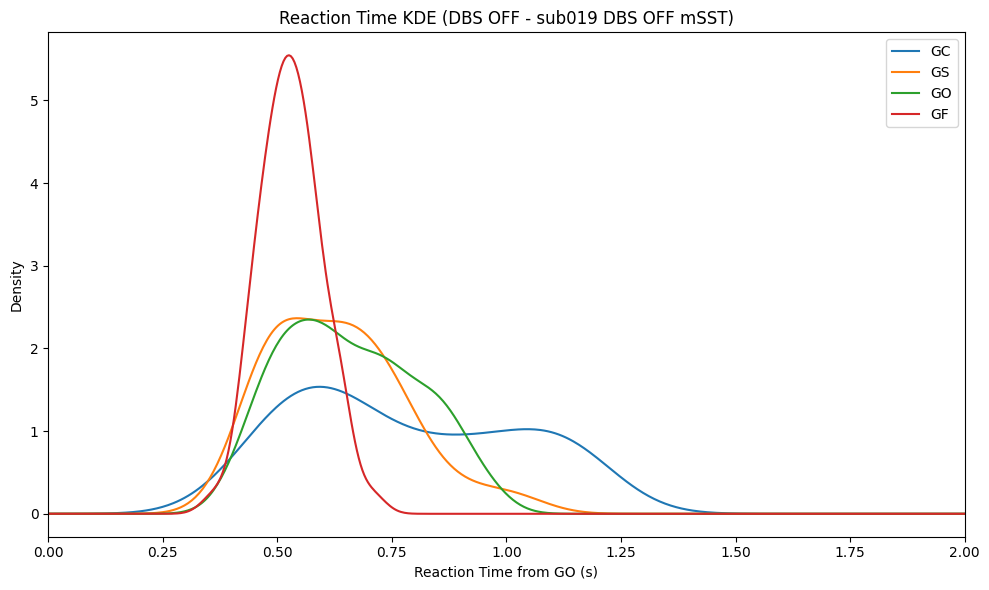

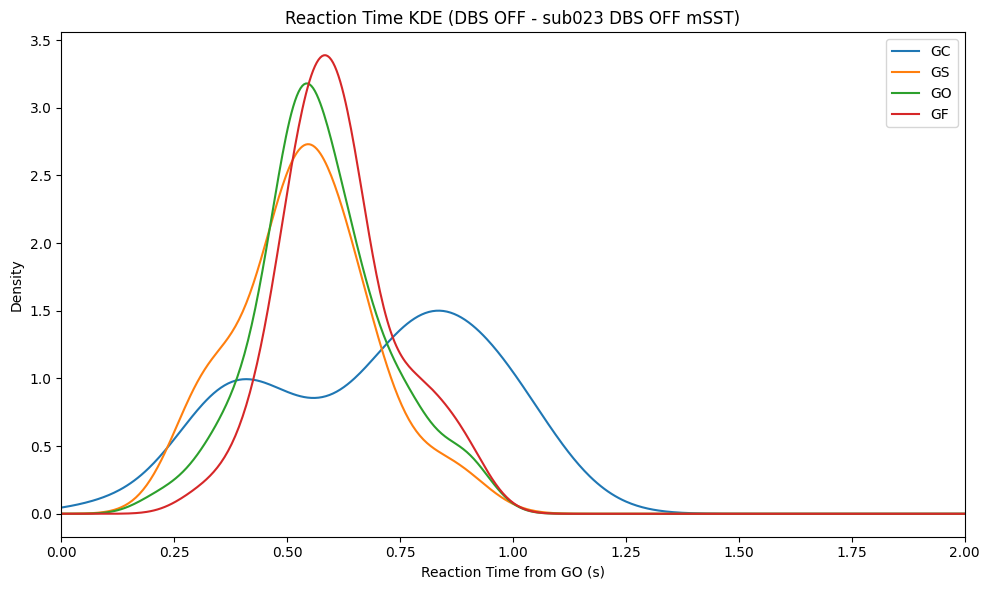

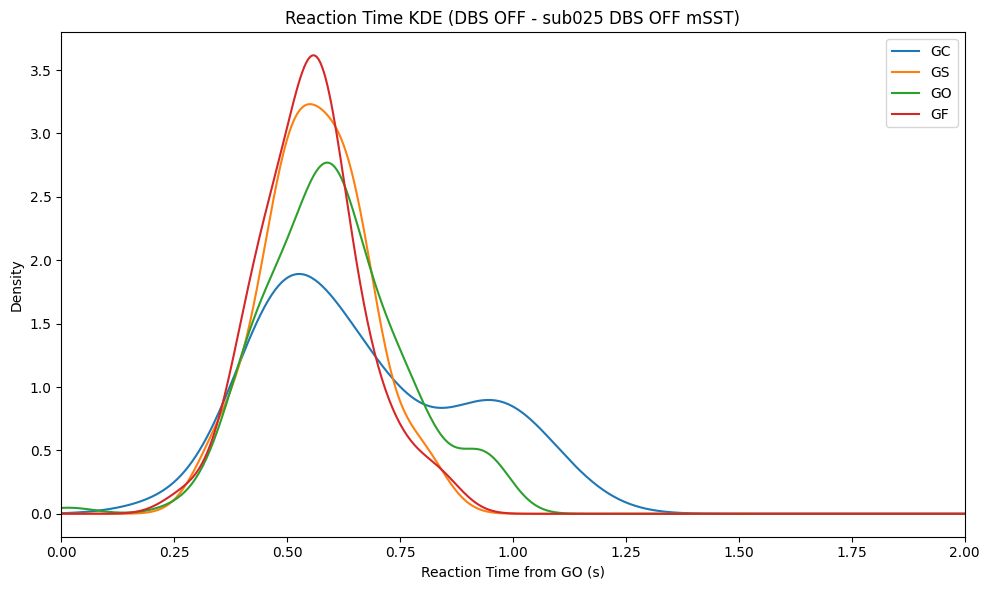

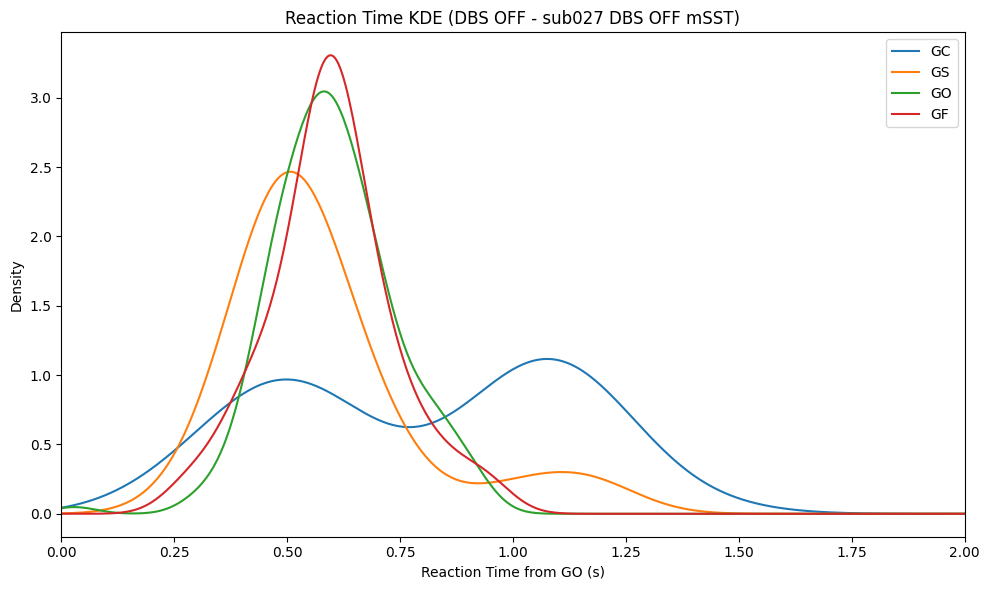

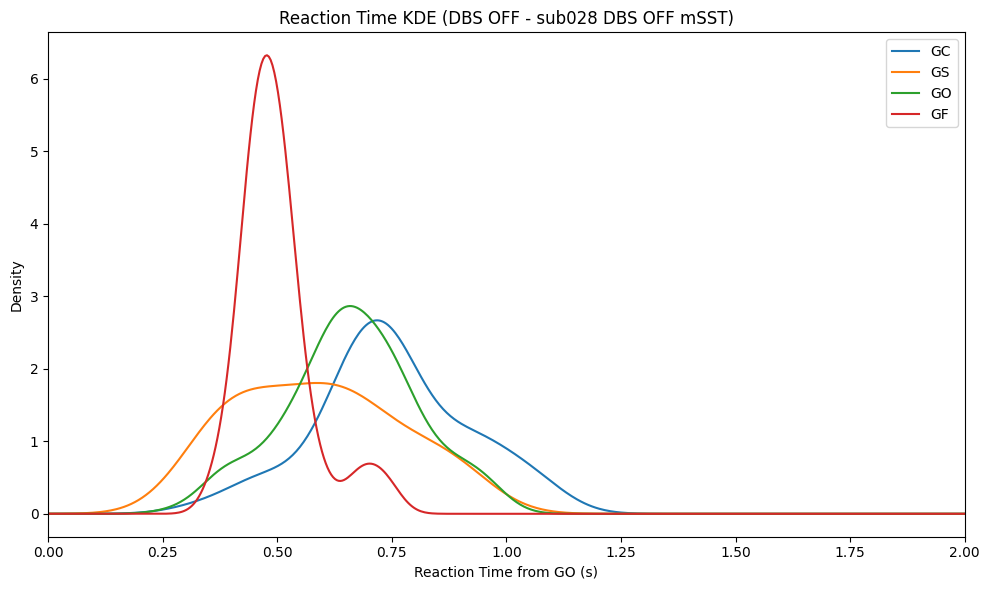

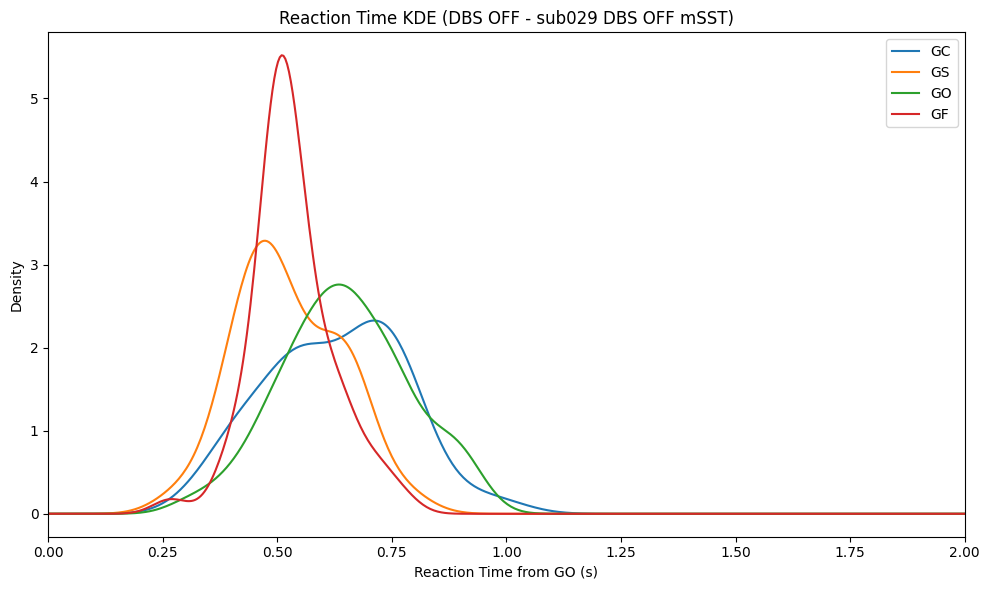

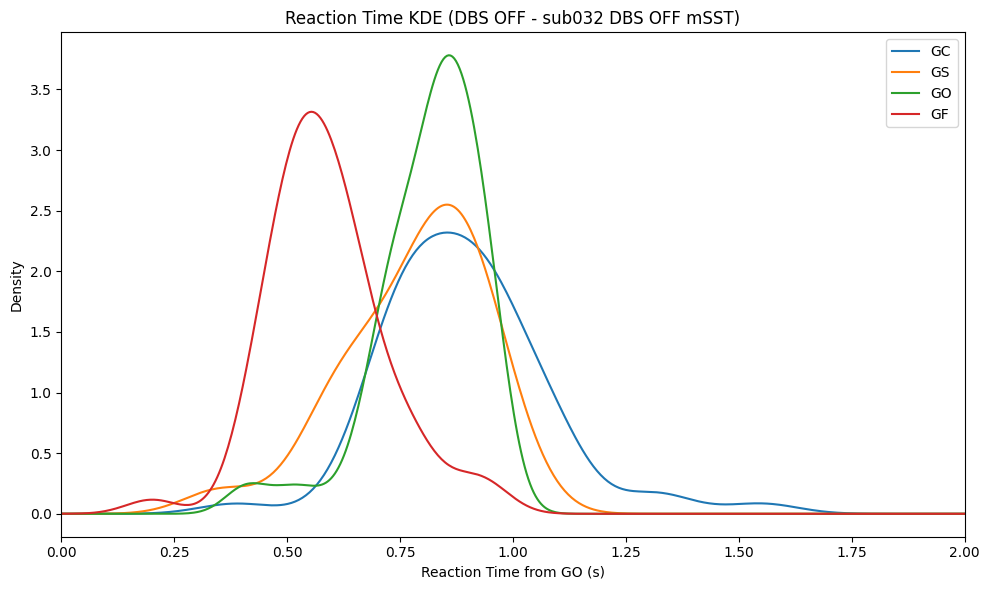

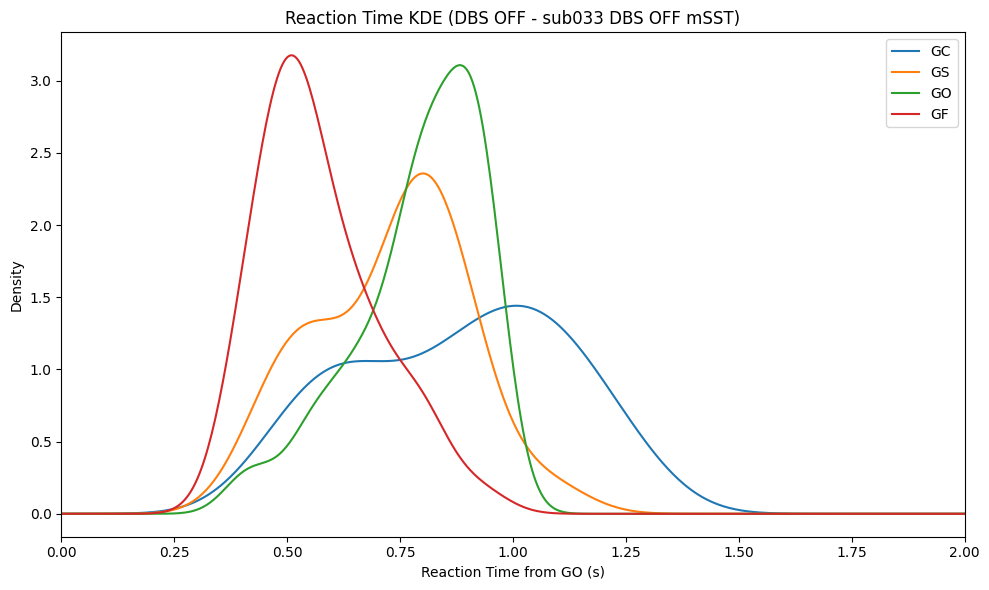

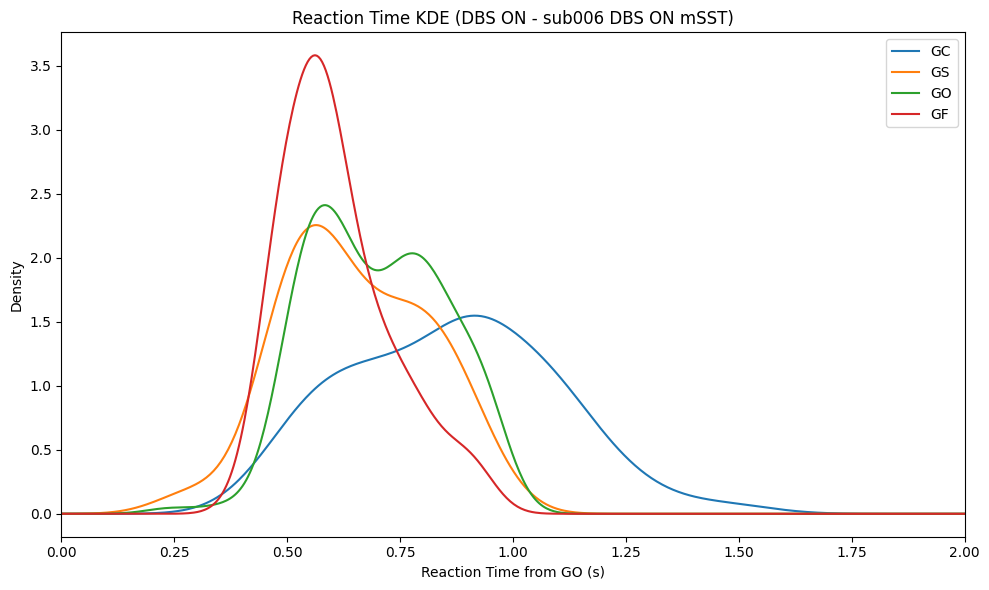

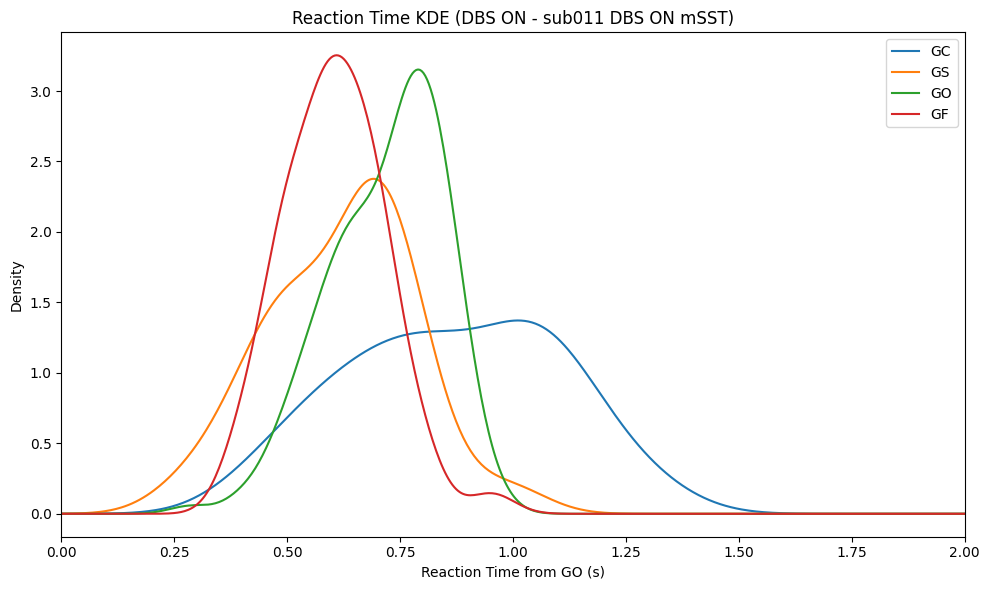

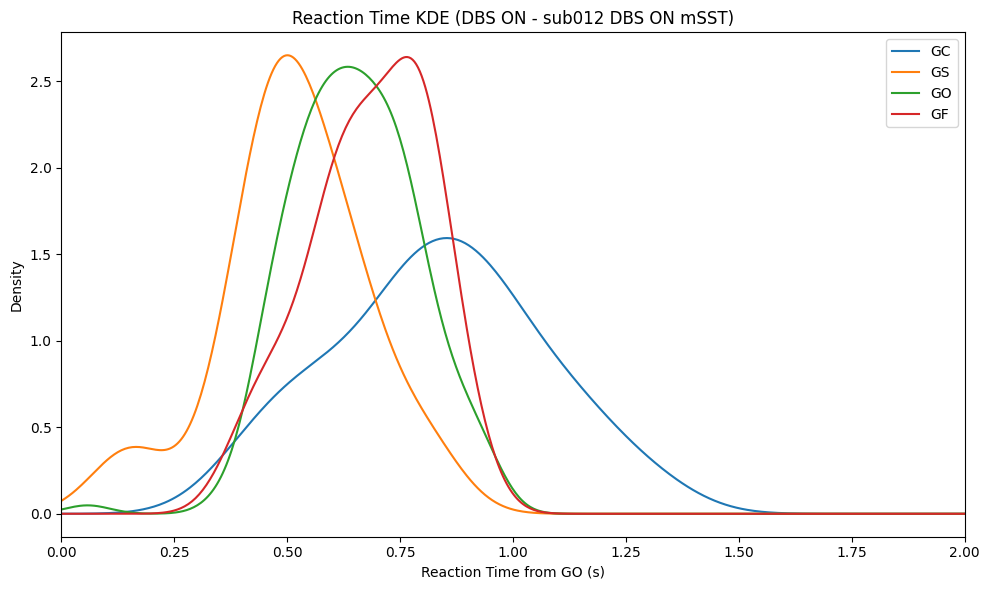

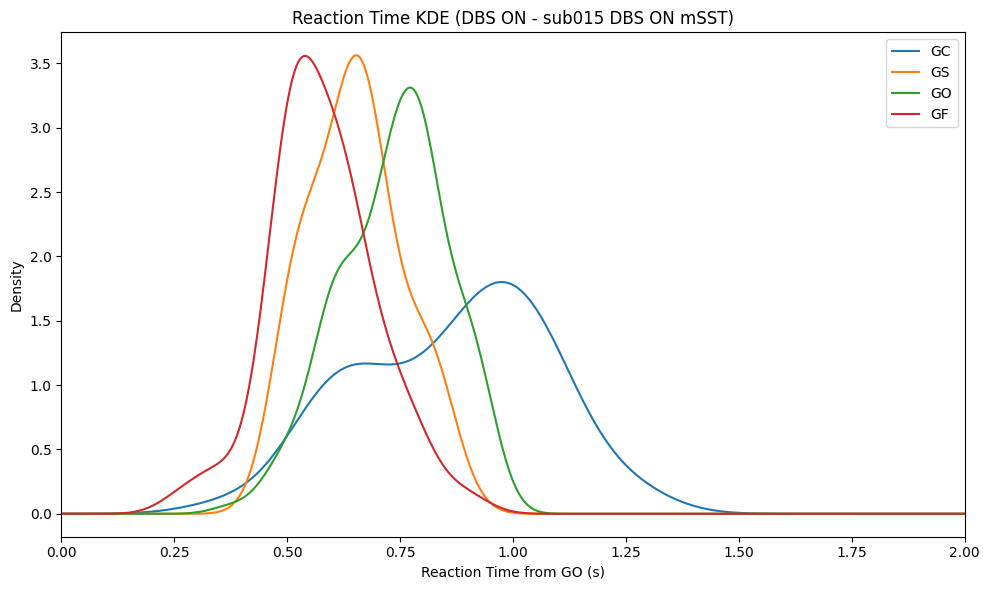

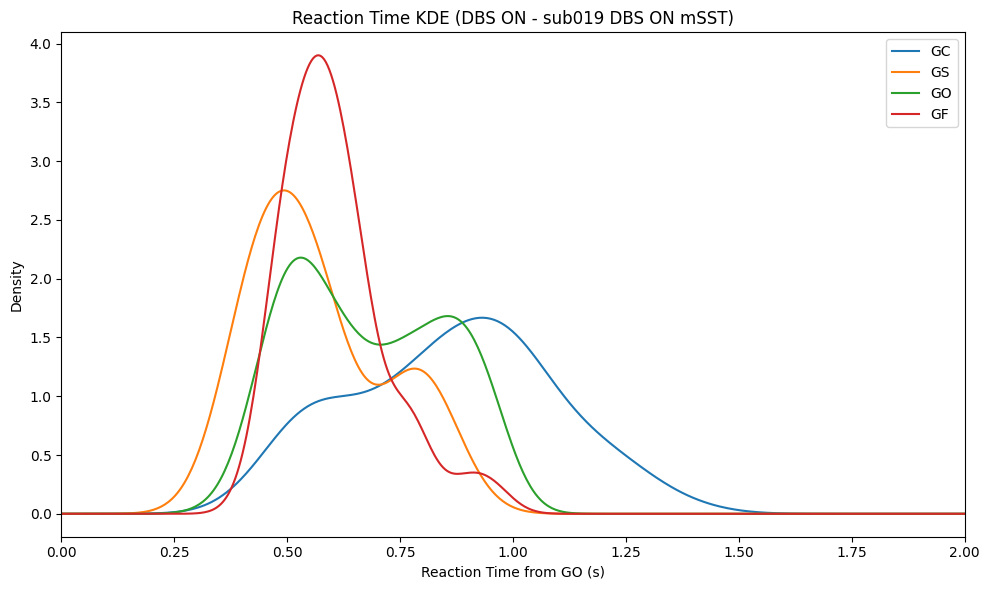

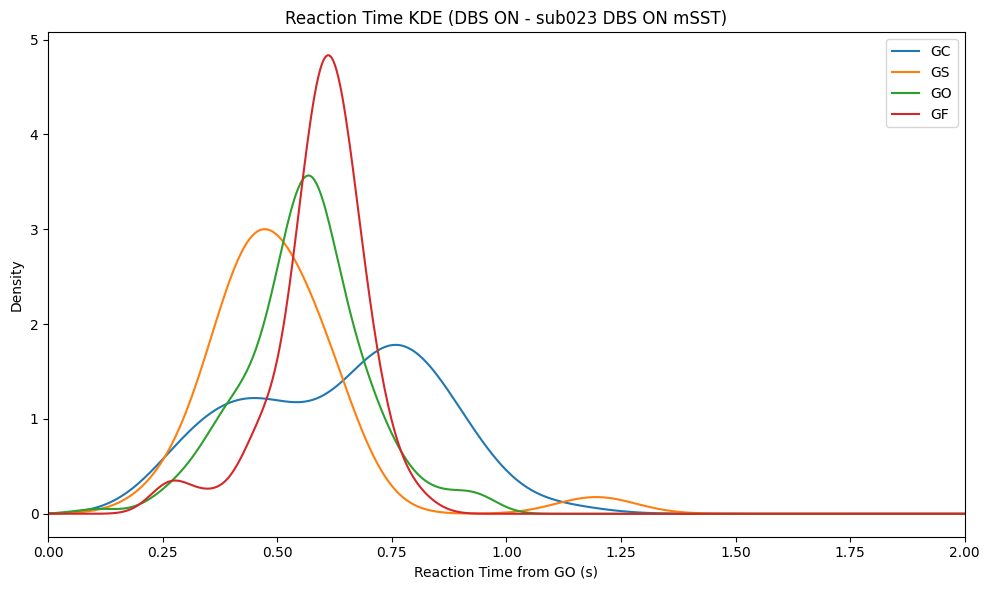

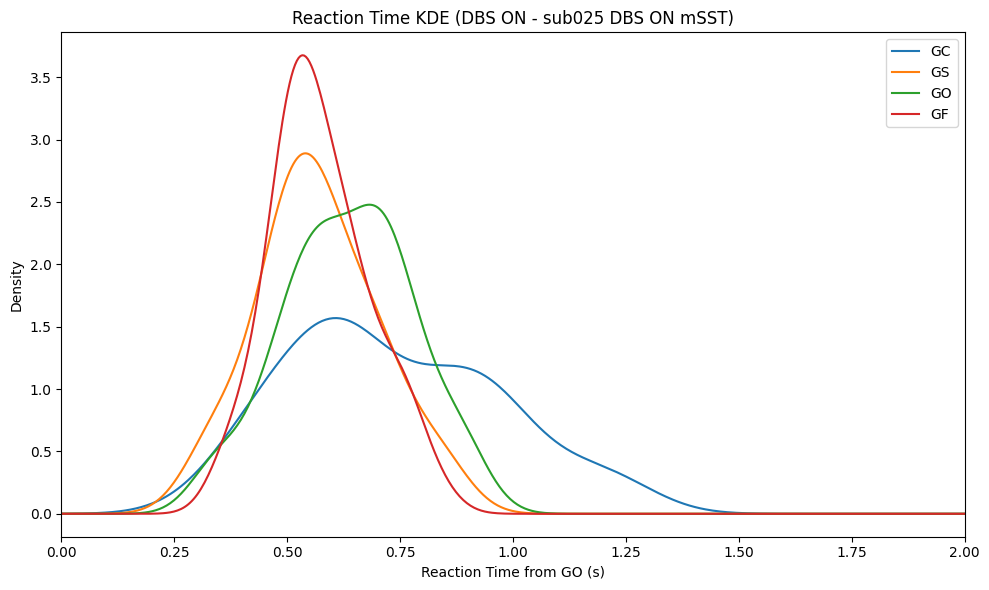

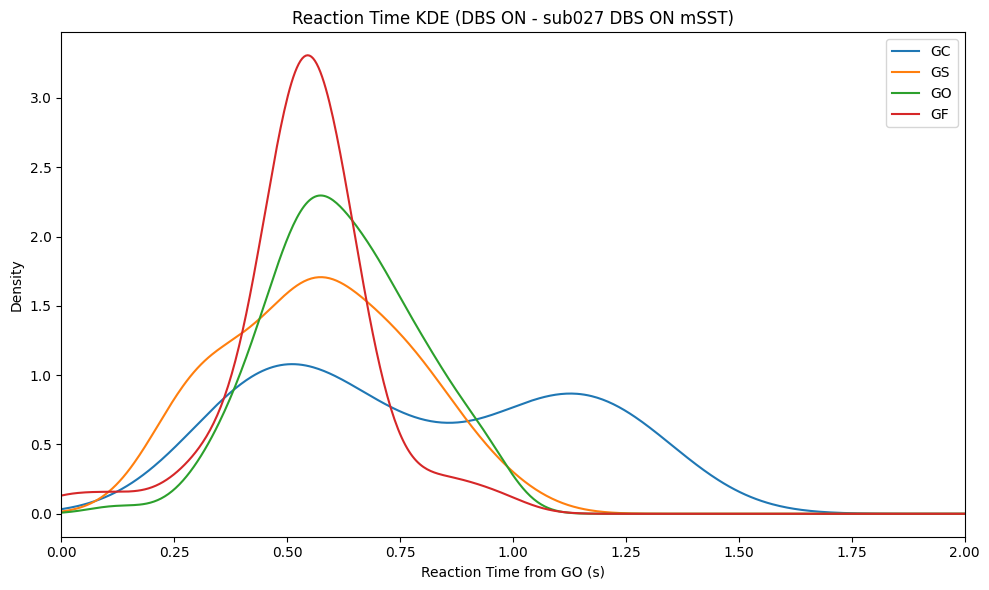

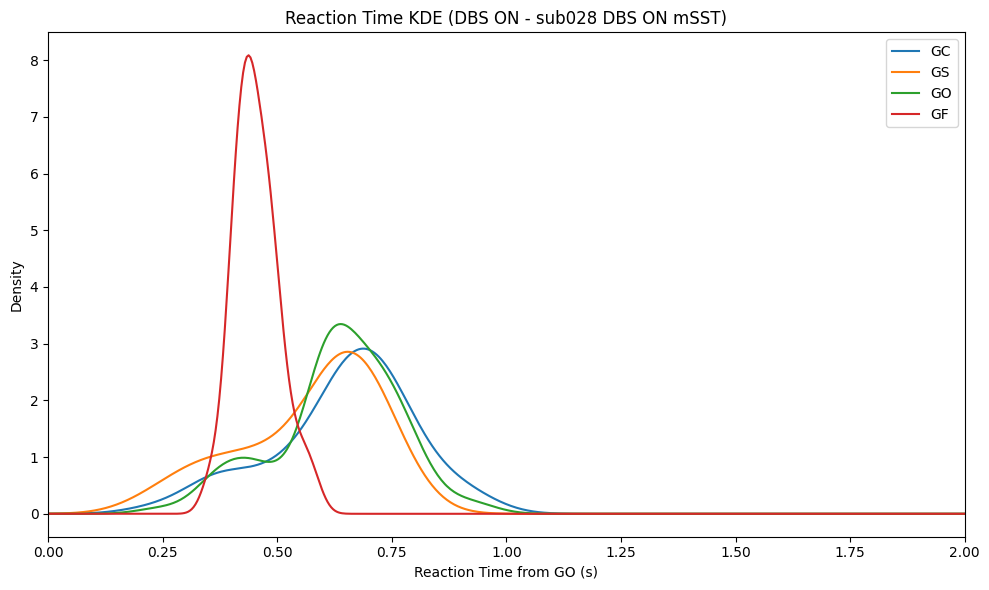

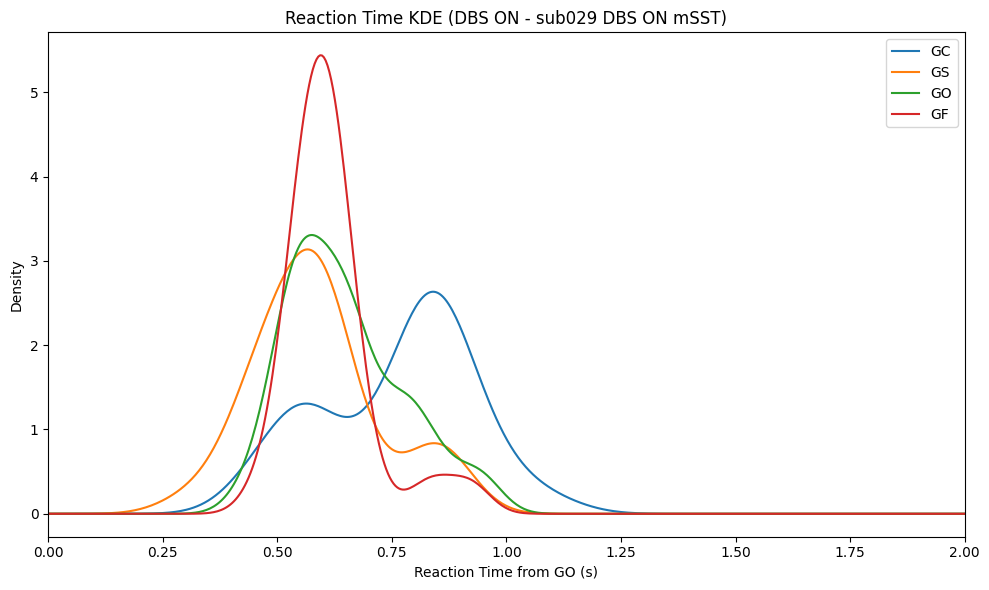

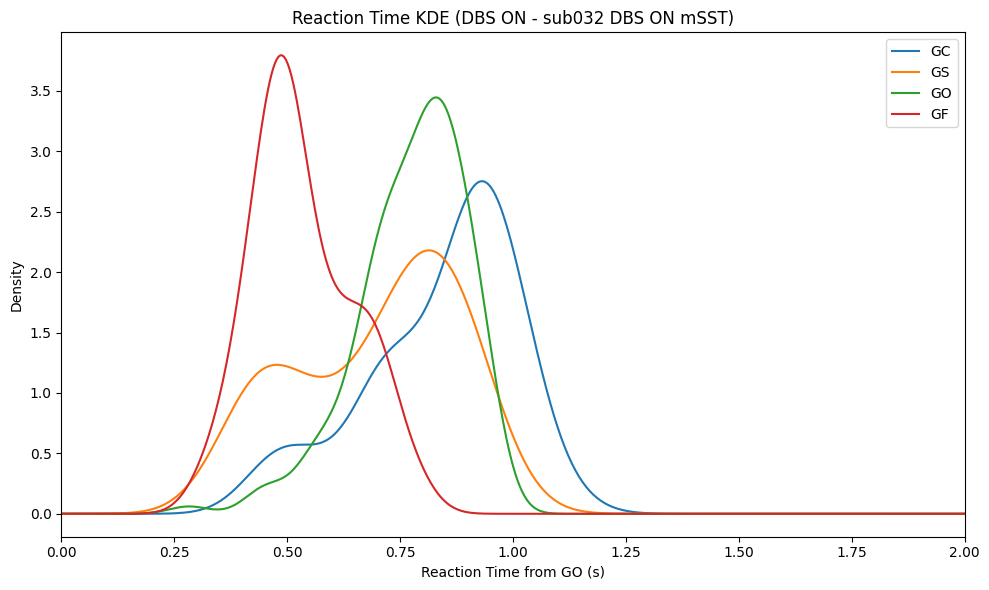

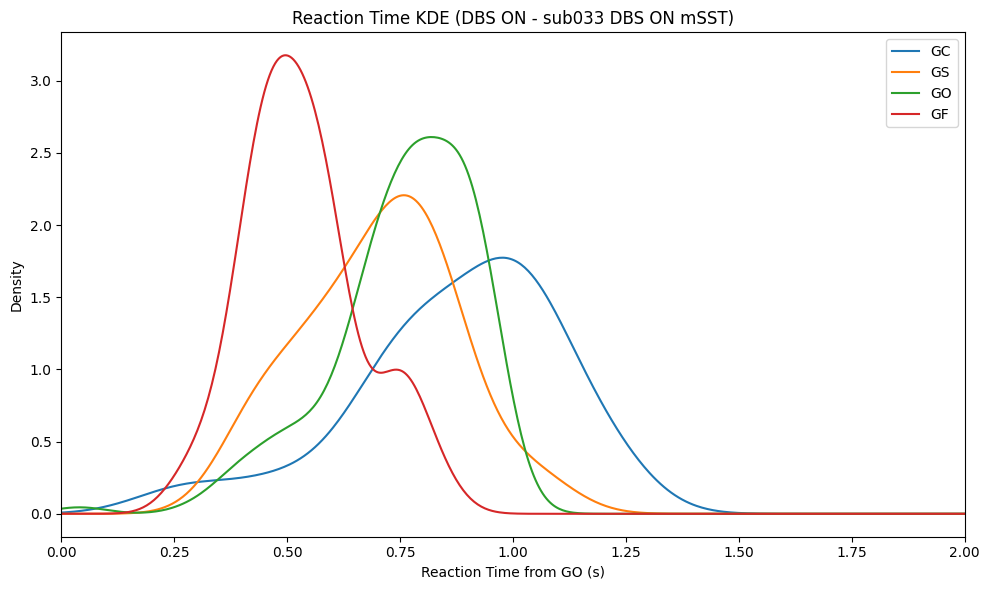

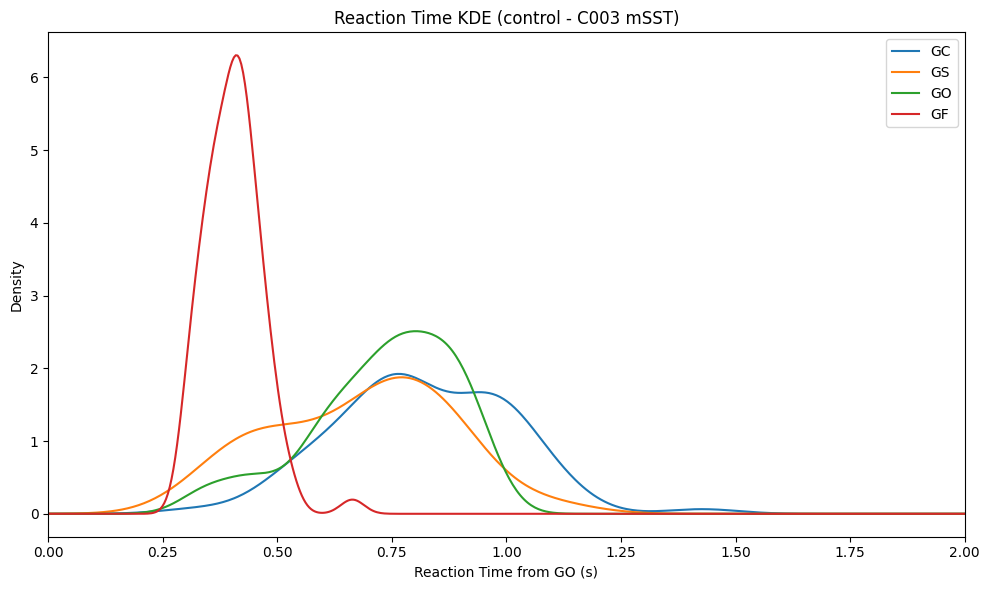

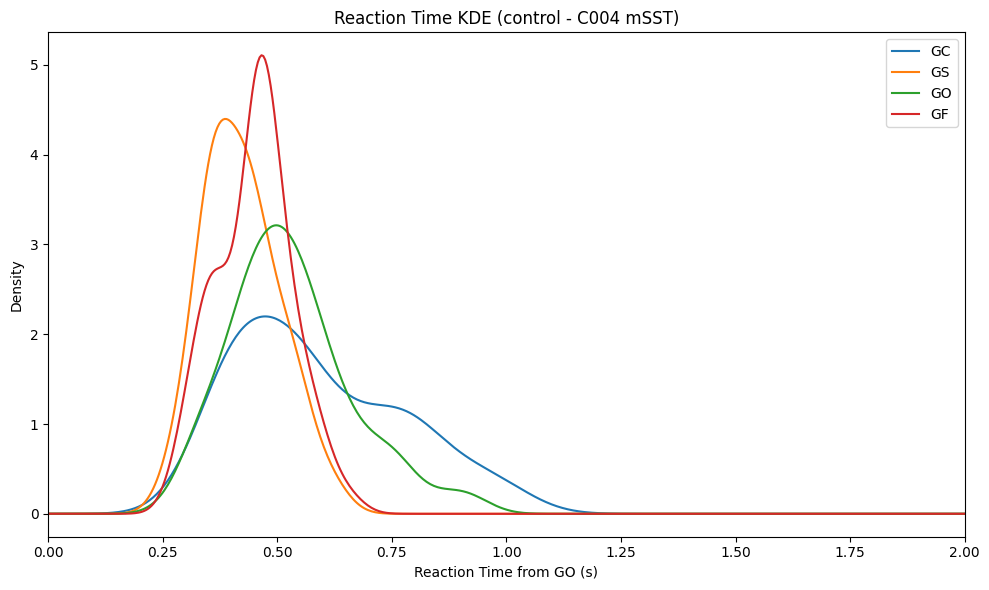

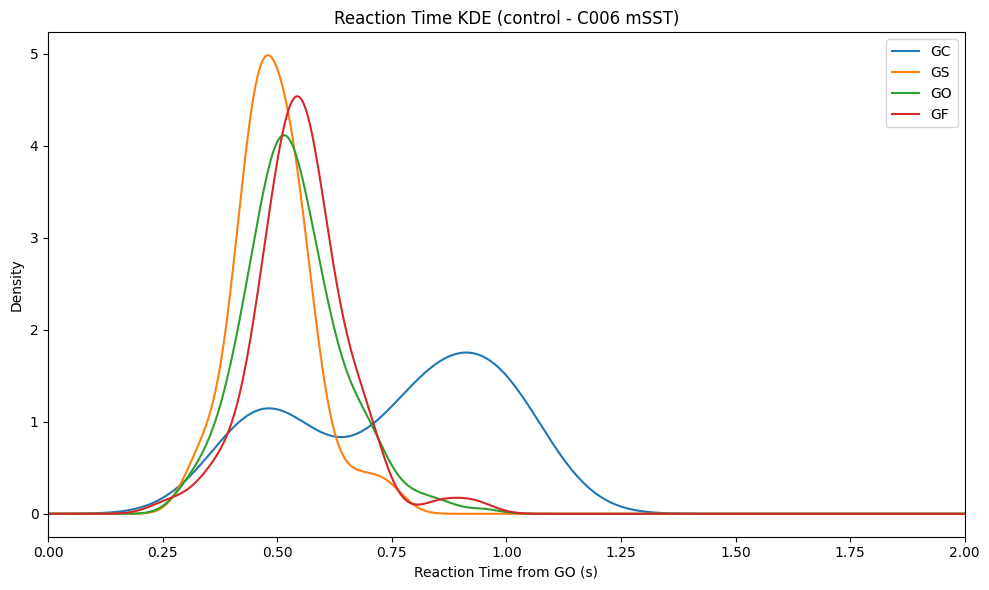

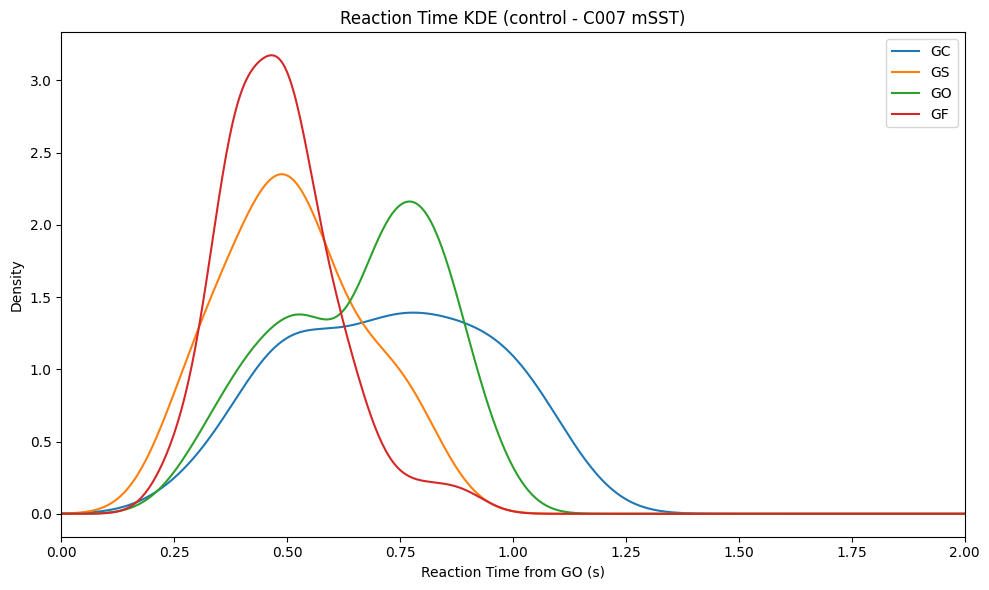

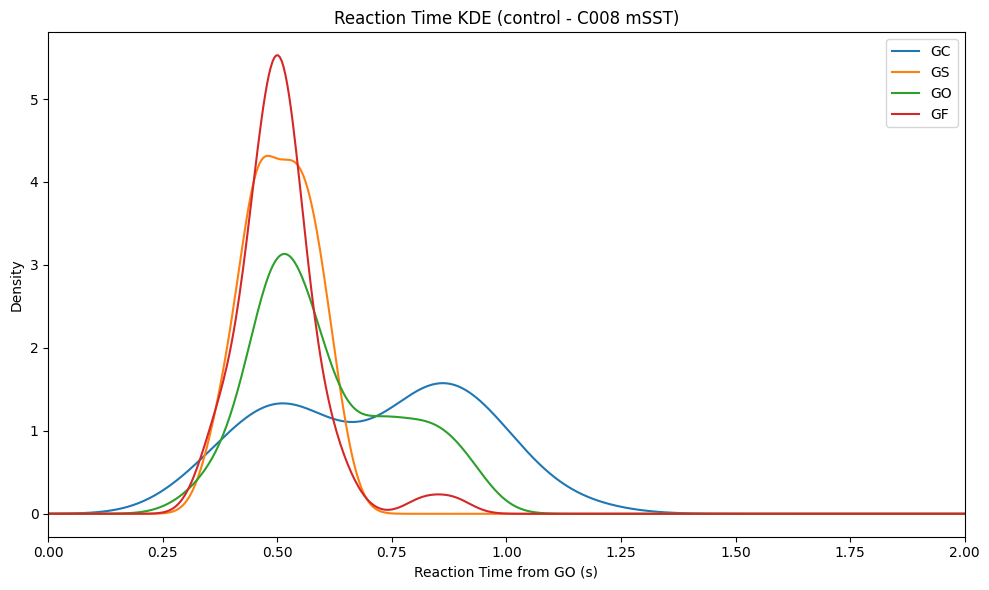

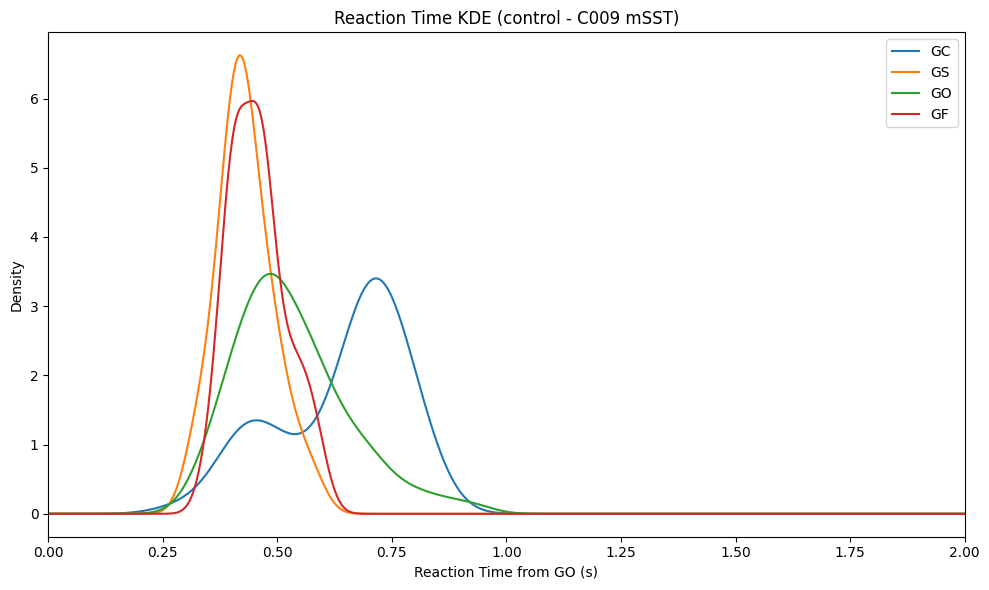

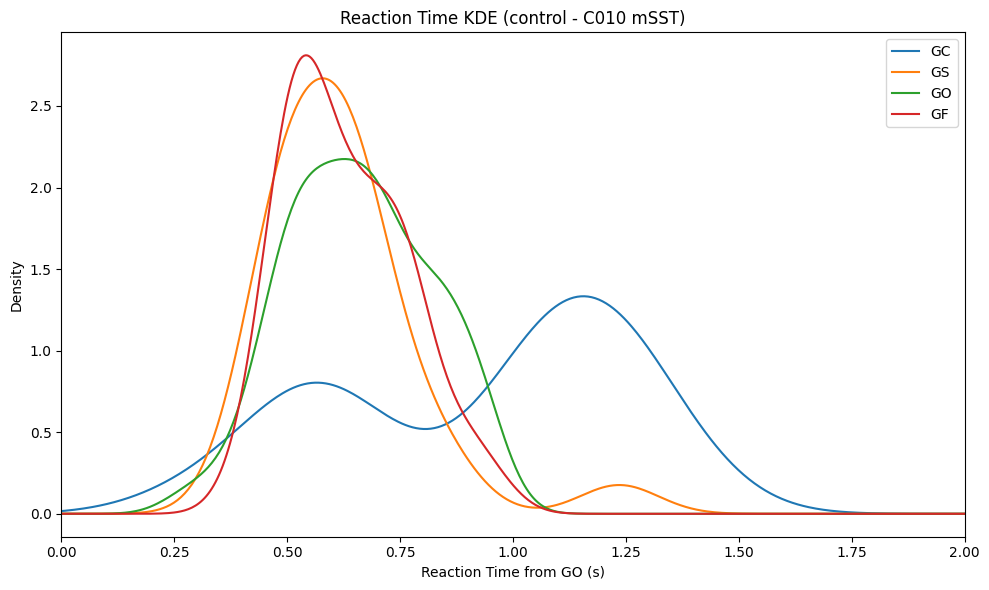

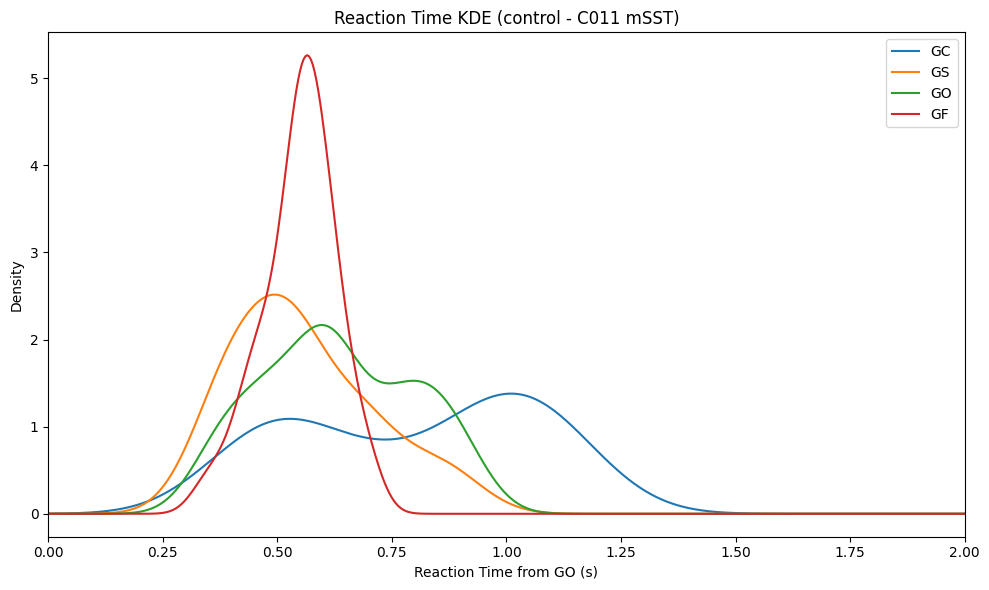

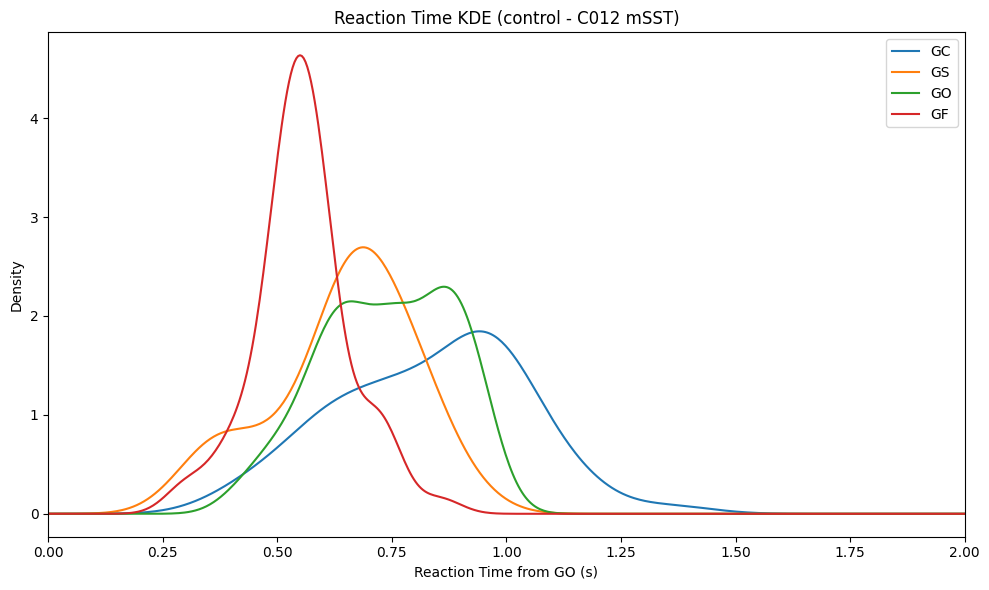

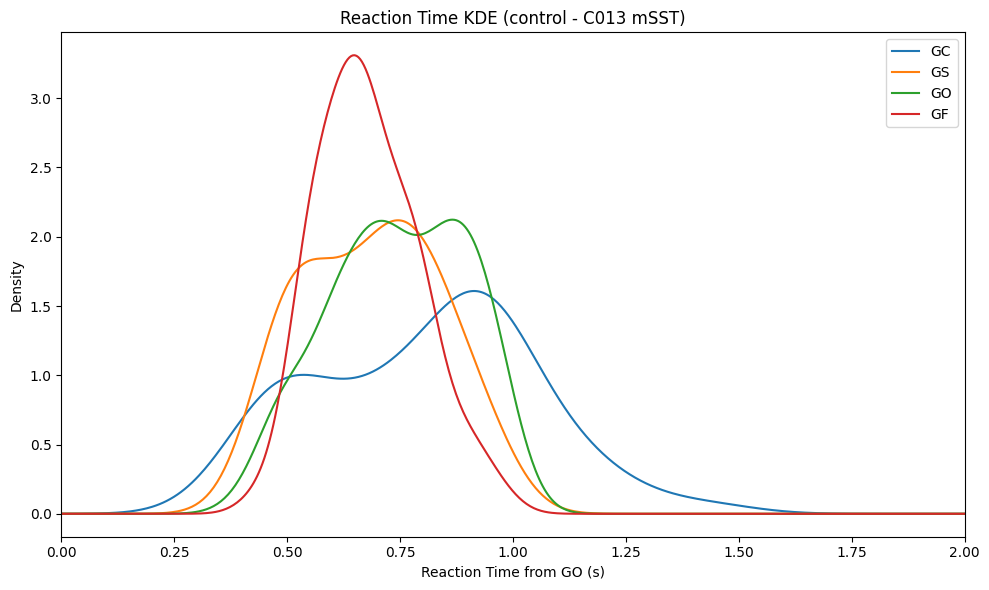

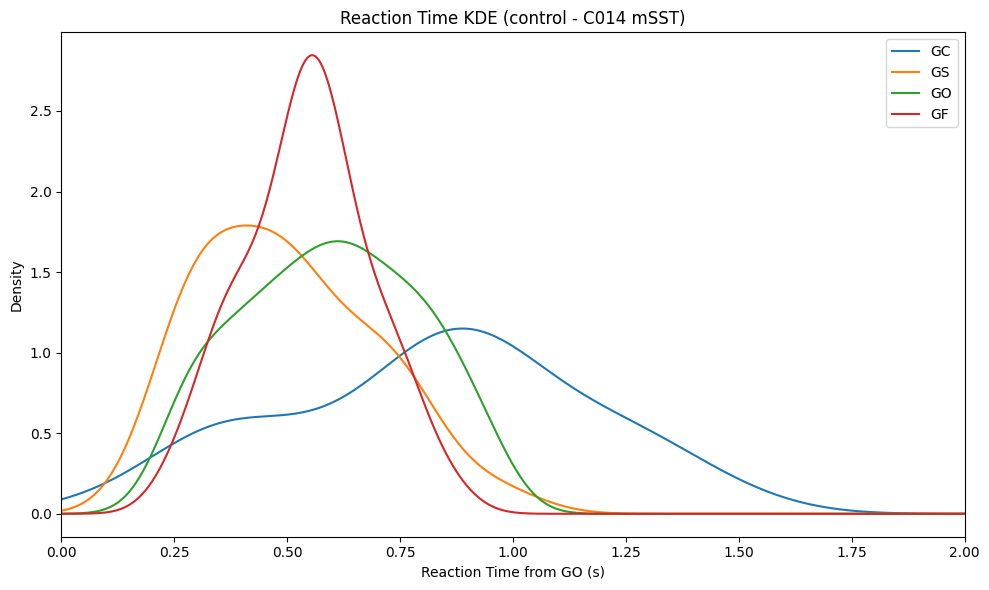

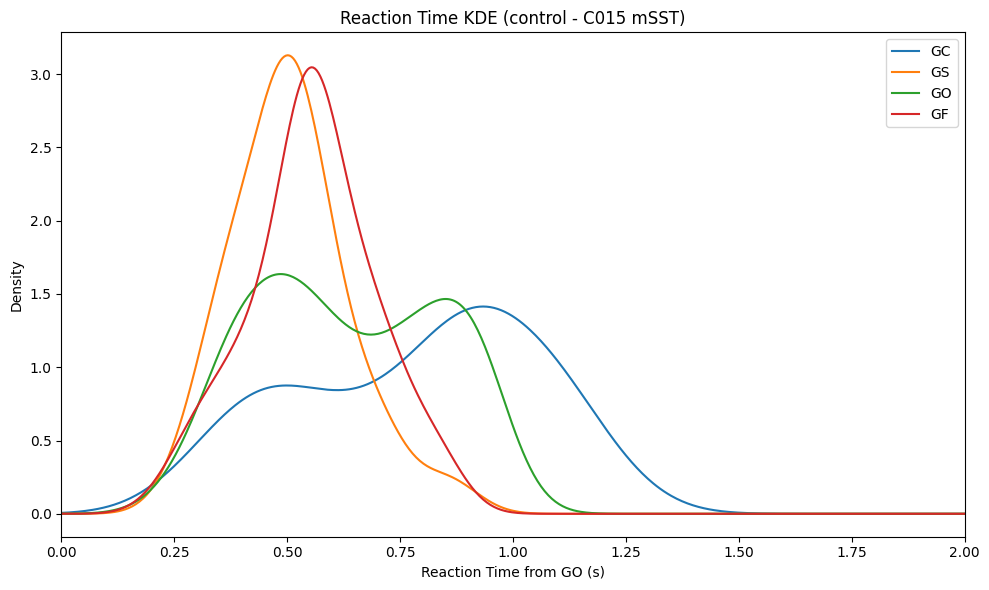

In [48]:
temp_save = join(behav_results_saving_path, "RT distribution", "single sub", "trial type comparison")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)  
behav_analysis.plot_kde_compare_trial_type_per_sub(
        stats, 
        color_dict, 
        save_path=temp_save, 
        save_as='png',
        show_plot = True)

## 3.3. Statistical analysis ##

Code and reasoning helped by Claude

### 3.3.1. Step 1: Is GC reliably bimodal in each subject/condition? ###

To answer this question, we fit for each subject and each condition separately a gaussian mixture model (GMM) with one component and with two components. Then we calculate the BIC (Bayesian Information Criterion)for each model. The lower the BIC, the better the model. The function will automatically count for how many subject/conditions the 2 component model is favored using the BIC.
The GMM is fitted on the RTs from GC trials computed from the Continue cue. It uses all the RTs from a session (not an average), expressed in seconds.

In [51]:
df_gc = stats_tests.build_gmm_summary_table(stats, trial_type='GC')
print(df_gc['favors_bimodal'].value_counts())
print([df_gc['subject'].iloc[i] for i in df_gc.index[df_gc['favors_bimodal'] == False]])
print([df_gc['condition'].iloc[i] for i in df_gc.index[df_gc['favors_bimodal'] == False]])

True     23
False     1
Name: favors_bimodal, dtype: int64
['sub032']
['DBS ON']


In [48]:
df_gc

,subject,condition,n_trials,weight_fast,weight_slow,mean_fast,mean_slow,std_fast,std_slow,bic_1comp,bic_2comp,favors_bimodal
0,sub006,DBS OFF,58,0.502685,0.497315,0.223989,0.551293,0.058862,0.078616,-27.657352,-48.945835,True
1,sub006,DBS ON,78,0.319155,0.680845,0.140501,0.591708,0.102955,0.132331,10.025763,4.145991,True
2,sub011,DBS OFF,71,0.354009,0.645991,0.164784,0.673439,0.086757,0.125847,23.268846,-0.247383,True
3,sub011,DBS ON,56,0.304809,0.695191,0.205105,0.606357,0.139927,0.083307,-6.803541,-20.751439,True
4,sub012,DBS OFF,56,0.247591,0.752409,0.303232,0.676301,0.042010,0.100352,-22.483799,-41.087407,True
5,sub012,DBS ON,52,0.225994,0.774006,0.333510,0.747192,0.097121,0.105346,-11.064724,-18.059978,True
6,sub015,DBS OFF,78,0.335942,0.664058,0.208562,0.618635,0.075719,0.100514,-9.852459,-35.531548,True
7,sub015,DBS ON,59,0.305085,0.694915,0.191882,0.593952,0.051066,0.062906,-17.633924,-73.520025,True
8,sub019,DBS OFF,58,0.568967,0.431033,0.121038,0.580465,0.064192,0.050763,4.723321,-66.079830,True
9,sub019,DBS ON,73,0.260261,0.739739,0.118539,0.649297,0.063369,0.099463,13.460589,-41.796895,True


Conclusion: Yes, robustly (23/24 subject-conditions)

### 3.3.2. Step 2: Does DBS shift the modes? ###

For this analysis we use the variables computed when we fitted the GMM model previously; the weights of each mode and their mean was saved in df_gc columns.
The compare_off_vs_on function will extract saved values per subject and compare OFF with ON values using both a wilcoxon signed-rank test (non-parametric version of the paired t-test) and a paired t-test. The wilcoxon null hypothesis is that two related paired samples come from the same distribution. The t-test null hypothesis is that two related or repeated samples have identical average (expected) values.

In [55]:
# does the balance between modes shift?
weight_dict_results = stats_tests.compare_off_vs_on(df_gc, metric='weight_fast')  
# weight_dict_results 

weight_fast: n = 12 subjects
  OFF mean = 0.399  |  ON mean = 0.306  |  mean diff (ON-OFF) = -0.092
  Wilcoxon signed-rank: W = 16.00, p = 0.0771
  Paired t-test:        t = 2.17, p = 0.0532


In [56]:
# does the fast mode's speed shift?
mean_fast_dict_results = stats_tests.compare_off_vs_on(df_gc, metric='mean_fast')

mean_fast: n = 12 subjects
  OFF mean = 0.199  |  ON mean = 0.186  |  mean diff (ON-OFF) = -0.013
  Wilcoxon signed-rank: W = 37.00, p = 0.9097
  Paired t-test:        t = 0.70, p = 0.4968


In [57]:
# does the slow mode's speed shift?
mean_slow_dict_results = stats_tests.compare_off_vs_on(df_gc, metric='mean_slow')

mean_slow: n = 12 subjects
  OFF mean = 0.577  |  ON mean = 0.583  |  mean diff (ON-OFF) = +0.007
  Wilcoxon signed-rank: W = 36.00, p = 0.8501
  Paired t-test:        t = -0.35, p = 0.7341


Conclusion: It shifts the weight toward the slow mode; it doesn't move either mode's speed.

In [ ]:
def plot_paired_metric(
        df, 
        metric='weight_fast', save_path=None, save_as='png',
        ylabel=None, title=None, show_plot=True
        ):
    """Spaghetti plot: one line per subject, DBS OFF -> DBS ON."""
    wide = df.pivot(index='subject', columns='condition', values=metric).dropna()

    fig, ax = plt.subplots(figsize=(5, 6))
    for subj, row in wide.iterrows():
        ax.plot(['DBS OFF', 'DBS ON'], [row['DBS OFF'], row['DBS ON']],
                marker='o', color='grey', alpha=0.6)

    means = wide.mean()
    ax.plot(['DBS OFF', 'DBS ON'], [means['DBS OFF'], means['DBS ON']],
            marker='o', color='black', linewidth=3, label='Group mean')

    ax.set_ylabel(ylabel or metric)
    ax.set_title(title or f'{metric}: DBS OFF vs ON (GC trials)')
    ax.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(join(save_path, f'{metric}_paired_plot.{save_as}'),
                     dpi=300, bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close()


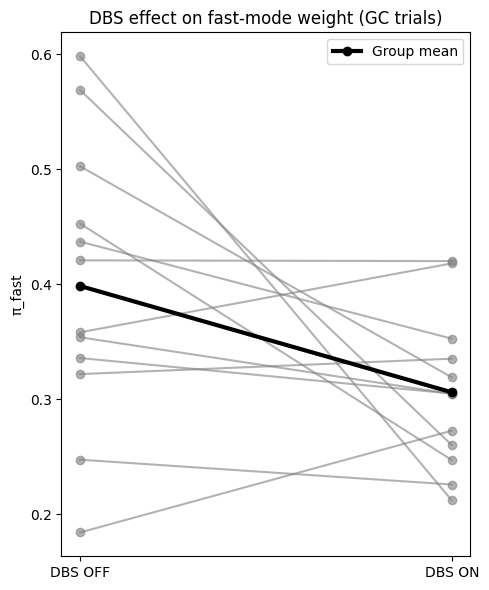

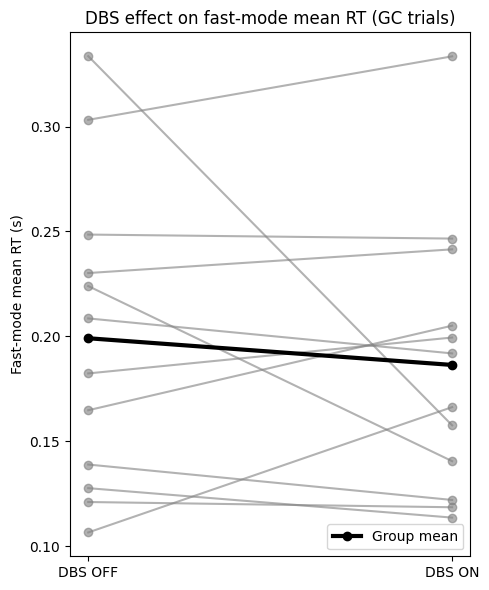

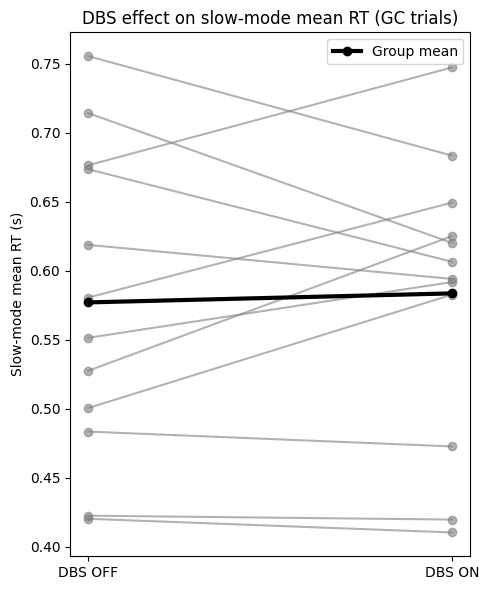

In [ ]:
# Figure 1c, 1d, 1e
temp_save = join(behav_results_saving_path, "RT distribution", "GMM summary")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)

plot_paired_metric(
    df = df_gc, 
    metric = 'weight_fast', 
    save_path = temp_save,
    save_as = save_as,
    ylabel ='π_fast',
    title = 'DBS effect on fast-mode weight (GC trials)',
    show_plot = True
    )

plot_paired_metric(
    df = df_gc, 
    metric = 'mean_fast', 
    save_path = temp_save,
    save_as = save_as,
    ylabel ='Fast-mode mean RT (s)',
    title = 'DBS effect on fast-mode mean RT (GC trials)',
    show_plot = True
    )

plot_paired_metric(
    df = df_gc, 
    metric = 'mean_slow', 
    save_path = temp_save,
    save_as = save_as,
    ylabel ='Slow-mode mean RT (s)',
    title = 'DBS effect on slow-mode mean RT (GC trials)',
    show_plot = True
    )


### 3.3.3. Step 3: How does GS relate? ###

Here we want to know if unsuccessful GS trial could come from the same distribution as fast GC trials (which would mechanistically make sense, as slow GS don't exist because they correspond to properly inhibited trials, i.e. trials with no button press.)
And we also want to assess whether DBS changes how GS and GC RTs distribution relate to each other.
To analyze that, we compare GS RTs computed from the Stop cue to GC RTs from the fast mode in single subject/per condition. 

In [65]:
importlib.reload(stats_tests)

<module 'functions.stats_tests' from 'c:\\Users\\Juliette\\Research\\Projects\\analysis_mSST\\scripts\\functions\\stats_tests.py'>

In [66]:
comparison_gs_gc_results = stats_tests.compare_gs_with_gc_fast_mode(stats)


DBS OFF: GS mean RT vs GC mean_fast (n=12)
  GS mean = 0.248  |  GC fast mean = 0.199  |  gap = +0.049
  Wilcoxon: W = 10.00, p = 0.0210

DBS ON: GS mean RT vs GC mean_fast (n=12)
  GS mean = 0.231  |  GC fast mean = 0.186  |  gap = +0.045
  Wilcoxon: W = 3.00, p = 0.0024

Does the GS-vs-GCfast gap change with DBS? (n=12)
  gap OFF = +0.049  |  gap ON = +0.045
  Wilcoxon: W = 32.00, p = 0.6221


Three comparisons are performed:
1. In DBS OFF,  is the mean RT of GS trials different from the fast mode mean of GC trials? --> comparison using wilcoxon --> sig. different (GS RT 49ms slower)
2. In DBS ON,  is the mean RT of GS trials different from the fast mode mean of GC trials? --> comparison using wilcoxon --> sig. different (GS RT 45ms slower)
3. GS and GC means are different both in DBS OFF and DBS ON, but is the gap itself different with DBS? --> comparison using wilcoxon (gap OFF = +0.049; gap ON = +0.045) --> not sig. (p=0.6221)

Conclusion: It tracks GC's fast mode closely and stays stable across DBS — the fast pathway itself looks untouched by stimulation.

In [ ]:
def plot_gs_vs_gc_fast_overlay(stats, pooled_params, save_path=None,
                                save_as='png', title=None, show_plot=True):
    """
    Overlay the empirical GS RT density with the GC fast-mode Gaussian
    component (from fit_pooled_gmm_per_subject), one panel per DBS
    condition, to visualize Step 3: GS closely tracks GC's fast mode, and
    that relationship is stable across DBS.
    """
    rt_key_map = {'GS': 'GS RTs from stop cue (ms)'}
    x = np.linspace(0, 1, 1000)
    off_subjects = {k: v for k, v in stats.items() if 'OFF' in k}

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    for ax, cond_label in zip(axes, ['DBS OFF', 'DBS ON']):
        gs_curves, fast_gaussians = [], []
        for off_key, off_data in off_subjects.items():
            on_key = off_key.replace('OFF', 'ON')
            if on_key not in stats:
                continue
            subj_id = off_key.split(' ')[0]
            if subj_id not in pooled_params:
                continue

            data = off_data if cond_label == 'DBS OFF' else stats[on_key]
            rts = np.asarray(data.get(rt_key_map['GS'], []), dtype=float)
            rts = rts[np.isfinite(rts)] / 1000.0
            if len(rts) > 1 and len(np.unique(rts)) > 1:
                gs_curves.append(scipy.stats.gaussian_kde(rts)(x))

            p = pooled_params[subj_id]
            fast_gaussians.append(
                scipy.stats.norm.pdf(x, loc=p['mean_fast'], scale=p['sd_fast']))

        gs_mean = np.array(gs_curves).mean(axis=0)
        fast_mean = np.array(fast_gaussians).mean(axis=0)
        # normalize the fast-mode Gaussian to a comparable peak height for display
        fast_mean = fast_mean / fast_mean.max() * gs_mean.max()

        ax.plot(x, gs_mean, color='crimson', label='GS (failed-stop) RTs', linewidth=2)
        ax.plot(x, fast_mean, color='steelblue', linestyle='--',
                label="GC fast-mode component", linewidth=2)
        ax.set_title(cond_label)
        ax.set_xlabel('Reaction time (s)')
        ax.legend(fontsize=8)

    axes[0].set_ylabel('Density (arbitrary units)')
    fig.suptitle(title or 'GS RTs vs. GC fast-mode component')
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(join(save_path, f'gs_vs_gc_fast_overlay.{save_as}'),
                     dpi=300, bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close()

Pooled 2-component model favored for 11/12 subjects.


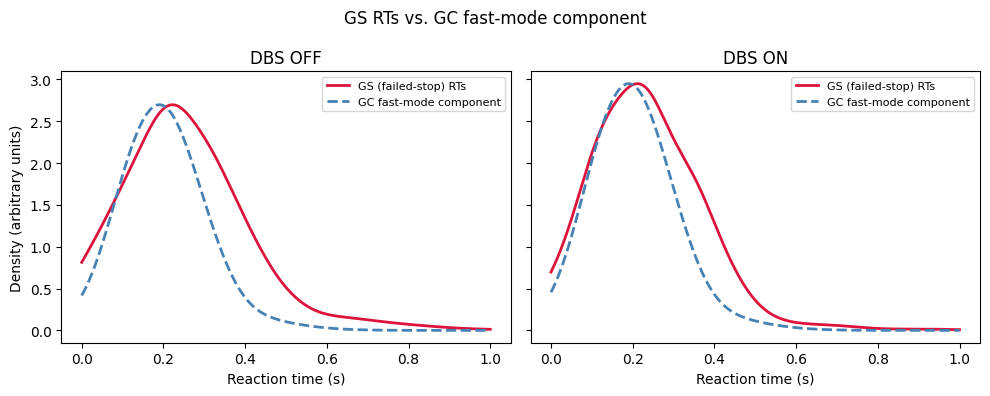

In [85]:
# Figure 1f:
temp_save = join(behav_results_saving_path, "RT distribution", "GMM summary")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)

pooled_params = stats_tests.fit_pooled_gmm_per_subject(
    stats = stats,
    trial_type = 'GC',
    rt_key_map = {
        'GC': 'GC RTs from continue cue (ms)',
        'GS': 'GS RTs from stop cue (ms)',
        'GO': 'go_trial RTs (ms)',
        'GF': 'go_fast_trial RTs (ms)',
    },
    n_init = 10,
    random_state = 0,
    min_trials = 20
    )
    
plot_gs_vs_gc_fast_overlay(
    stats = stats,
    pooled_params = pooled_params,
    save_path = temp_save,
    save_as = save_as,
    title = 'GS RTs vs. GC fast-mode component',
    show_plot = True
    
)

Conclusion and interpretation on RT analysis (reply from Claude):

# DBS effects on reaction times in the mSST

---

## Methods

### Task and trial types

Participants performed a modified stop-signal task, recorded once under DBS
OFF and once under DBS ON (n = 12 matched sessions). Four trial types were
analyzed: **GC** (go square followed by a "continue" triangle; respond and
ignore the triangle), **GS** (go square followed by a "stop" triangle;
withhold response when possible — only failed-stop RTs are available), **GO**
(go square alone), and **GF** (a visually distinct "fast-go" square alone).

### Step 0 — Does DBS affect RT, and does this depend on trial type?

RTs from all trials and subjects were analyzed with a linear mixed-effects
model:

```
RT ~ Condition * Trial_type
random intercept + random Condition slope per subject
```

with GO and DBS-OFF as reference levels. The Condition × Trial_type
interaction terms test whether the effect of DBS on RT differs by trial
type.

### Step 1 — Is the GC RT distribution bimodal?

For each subject and condition separately, a 1-component and a 2-component
Gaussian mixture model (GMM) were fit to the raw GC RTs, and BIC was used to
select between them (lower BIC preferred). This was done per subject/session
rather than assumed, so that "bimodal" is an empirically supported
description rather than a visual impression from the KDE plots.

### Step 2 — Do the two modes' weights or locations change with DBS?

For subject/condition cells where the 2-component model was favored, the
GMM yields a fast-mode weight (π<sub>fast</sub>), a slow-mode weight
(1 − π<sub>fast</sub>), and the two mode locations (mean<sub>fast</sub>,
mean<sub>slow</sub>). Each of these three quantities was compared between
DBS OFF and ON with paired Wilcoxon signed-rank tests (primary, robust to
the non-normal/bounded nature of mixture weights at this sample size) and
paired t-tests (reported alongside).

### Step 3 — How does GS relate to GC's fast mode?

Because GS RTs exist only for failed-stop trials — a selection-biased
sample of the fastest, most motorically-committed responses, not an
independent trial-type distribution — GS was not modeled with its own GMM.
Instead, per-subject GS mean RT was compared directly to the location of
the GC fast mode (mean<sub>fast</sub>), separately for each DBS condition
(paired Wilcoxon), and the OFF/ON stability of this relationship was tested
by comparing the gap (GS mean RT − GC mean<sub>fast</sub>) between
conditions.

---

## Results

### DBS slows RT specifically on GC trials

The top-down LMM showed no DBS effect on RT at the GO baseline (β = 1.25 ms,
*SE* = 12.03, *z* = 0.10, *p* = .917). Trial types differed substantially in
RT at baseline: GC trials were slower than GO (β = 96.08 ms, *p* < .001),
while GS (β = −63.27 ms, *p* < .001) and GF (β = −94.11 ms, *p* < .001) were
faster. Critically, the Condition × Trial-type interaction was significant
for GC only (β = 29.12 ms, *SE* = 9.75, *z* = 2.99, *p* = .003) — DBS
increased GC RT by ~29 ms more than it affected GO — while the GS (*p* =
.465) and GF (*p* = .553) interactions were not significant. **DBS therefore
does not produce a general RT change in this task; its effect is specific to
GC trials.**

### GC RTs are reliably bimodal

The 2-component GMM was favored by BIC in 23 of 24 subject × condition
cells (the single exception being one subject's DBS-ON session). GC's RT
distribution is thus not merely visually suggestive of two modes — a
two-component model is empirically justified for nearly every subject in
both conditions.

### DBS reallocates weight between the modes without moving them

The fast-mode weight decreased under DBS ON relative to OFF (OFF *M* =
0.399, ON *M* = 0.306; Wilcoxon *p* = .077; paired *t*-test *p* = .053), a
medium-sized effect (*d*<sub>z</sub> ≈ 0.63) consistent in direction across
9 of 12 subjects. By contrast, neither mode's location changed: mean
<sub>fast</sub> (0.199 s vs. 0.186 s, *p* = .91) and mean<sub>slow</sub>
(0.577 s vs. 0.583 s, *p* = .85) were statistically indistinguishable
between conditions. **DBS shifts how much RT mass falls in the slow mode,
not how fast either mode is.** This directly explains the Step-0 LMM result:
a mixture's pooled mean is a weighted average of its component means
(π<sub>fast</sub>·mean<sub>fast</sub> + π<sub>slow</sub>·mean<sub>slow</sub>),
so shifting weight toward the (higher-value) slow component raises the
pooled mean even with both component locations fixed — the same weight
reallocation is what the LMM detected as a significant GC-specific slowing.

### GS RTs track the GC fast mode, independent of DBS

GS mean RT was reliably slower than the GC fast-mode location in both
conditions (OFF: 0.248 s vs. 0.199 s, gap = +0.049 s, *p* = .021; ON: 0.231
s vs. 0.186 s, gap = +0.045 s, *p* = .0024) — related but not identical
distributions, consistent with GS reflecting a further-selected subset of
the same fast/prepotent process. This gap did not differ between DBS
conditions (*p* = .622): **the relationship between GS and GC's fast mode
was unaffected by stimulation.**

---

## Interpretation

Together, these four steps support a coherent, specific conclusion: **DBS
does not generally slow or speed responding in this task. It selectively
increases the weight of the slow, controlled response mode on trials with
go/continue cue conflict (GC), while leaving the speed of both response
modes, and the behavior of conflict-free (GO, GF) and failed-stop (GS)
trials, unchanged.**

Mechanistically, we interpret GC's fast mode as reflecting responses
effectively already committed to before the near-simultaneous continue
triangle is processed — an automatic response to the go square — and the
slow mode as reflecting trials where the triangle triggers a covert braking
process that must then be overridden, since continuing to respond is the
correct action on GC trials. A DBS-related increase in slow-mode weight
indicates that stimulation increases how often this override process
engages, not how quickly it (or the automatic pathway) operates once
engaged.

This pattern is not what a simple "DBS improves motor speed" account
predicts — GO and GF, which share the same motor response but no cue
conflict, show no DBS effect at all. The specificity to GC instead points
toward the subthalamic nucleus's role in conflict-driven inhibitory control
(consistent with prior work implicating the hyperdirect pathway in
impulsivity/response arbitration), rather than a general effect on movement
initiation speed.

The GS results add convergent support: failed-stop RTs are closely, and
stably, tied to the location of GC's fast mode across both DBS conditions.
This indicates the fast/prepotent pathway itself — wherever it is sampled,
whether in GC's fast mode or in GS's failed-stop trials — is not what DBS
is acting on. DBS's effect is confined to the balance between that pathway
and the slower, controlled one, specifically when cue conflict is present.

**A note on statistical strength:** the Step-2 subject-level weight
comparison (n = 12) is only marginal on its own (*p* = .05–.08). We report
it because it is directly interpretable in terms of the mixture model, but
the more decisive evidence for the effect is the Step-0 trial-level LMM
interaction (*p* = .003, using all trials rather than 12 summary
statistics), which — as shown above — is not a separate finding but the
same weight-reallocation effect expressed at the level of trial-level mean
RT. We present the two as convergent lines of evidence at different levels
of analysis rather than as independent confirmations for the purposes of
any correction for multiple comparisons.


# Figures #

Figure 1. DBS selectively affects RT on conflict (GC) trials.
(A) Coefficients (± 95% CI) for the Condition × Trial-type interaction from the linear mixed-effects model (RT ~ Condition × Trial-type; GO and DBS-OFF as reference levels), shown for each trial type relative to GO. Points in red indicate an interaction whose CI excludes zero (GC only); grey points indicate no significant DBS-related RT change relative to GO (GS, GF). (B) Group-average RT density for GC trials (mean of per-subject kernel density estimates ± SEM), overlaid for DBS OFF (blue) and DBS ON (orange). The distribution is bimodal in both conditions, with a visible increase in the relative density of the slow mode under DBS ON.

Figure 2. DBS reallocates weight between GC's two response modes without changing their speed.
(A) Fast-mode weight (π<sub>fast</sub>), derived from a two-component Gaussian mixture model fit to each subject's GC RTs, plotted per subject for DBS OFF vs. ON (grey lines) with the group mean overlaid (black). Most subjects show a decrease under DBS ON. (B) Mean RT of the fast mode (left) and slow mode (right), same format as (A). Unlike the fast-mode weight, neither mode's location differs between conditions — the two panels together illustrate that DBS shifts the balance between modes rather than the speed of either one. (C) Group-average RT density for GS (failed-stop) trials (solid) overlaid with the fitted GC fast-mode Gaussian component (dashed), shown separately for DBS OFF and DBS ON. GS RTs closely track the location of GC's fast mode in both conditions, and this relationship is unchanged by DBS, indicating the fast/prepotent response pathway itself is not affected by stimulation.